# HMM 레짐 분석 (Hidden Markov Model Regime Analysis)

> **목적**: 시장 데이터를 기반으로 숨겨진 시장 상태(레짐)를 자동 탐지합니다.  
> **데이터**: FF 팩터, 매크로 지표, 일별 수익률, 섹터 ETF  
> **기간**: 2004 ~ 2026  

---


In [1]:
import subprocess, sys
pkgs = ["hmmlearn", "scikit-learn", "matplotlib", "seaborn", "nbformat"]
for p in pkgs:
    result = subprocess.run(
        ["uv", "pip", "install", p, "--python", sys.executable, "-q"],
        capture_output=True
    )
    if result.returncode != 0:
        # fallback
        subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"])
print("✅ 설치 완료")

✅ 설치 완료


## 0. 라이브러리 임포트

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import platform
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
SEED = 42

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


## 1. 경로 설정

In [3]:
BASE_DIR  = Path.cwd()
DATA_DIR  = BASE_DIR / 'data'
OUT_DIR   = BASE_DIR / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUT_DIR : {OUT_DIR}")

DATA_DIR: c:\workspace\camp\project\finance_project\서윤범\low_risk\data
OUT_DIR : c:\workspace\camp\project\finance_project\서윤범\low_risk\outputs


## 2. 데이터 로드 & 전처리

| 파일 | 설명 |
|------|------|
| `ff_factors_daily.csv` | Fama-French 5팩터 + 모멘텀 (일별) |
| `macro_daily.csv` | VIX, WTI, 금리스프레드 등 매크로 (일별) |
| `daily_returns.pkl` | 개별 종목 일별 수익률 (5,595일 × 822종목) |
| `sector_etf.pkl` | 섹터 ETF 가격 시계열 |


In [4]:
# ── FF 팩터 (일별) ──────────────────────────────────────────────────────────
ff = pd.read_csv(DATA_DIR / "ff_factors_daily.csv", parse_dates=["date"])
ff = ff.set_index("date").sort_index()

# ── 매크로 (일별) ────────────────────────────────────────────────────────────
macro = pd.read_csv(DATA_DIR / "macro_daily.csv", parse_dates=["date"])
macro = macro.set_index("date").sort_index()

# ── 일별 수익률 → 동일가중 시장 수익률 ──────────────────────────────────────
dr = pd.read_pickle(DATA_DIR / "daily_returns.pkl")
mkt_ret = dr.mean(axis=1).rename("mkt_ret_ew")

# ── 섹터 ETF ─────────────────────────────────────────────────────────────────
with open(DATA_DIR / "sector_etf.pkl", "rb") as f:
    sector_raw = pickle.load(f)
sector_df  = pd.DataFrame(sector_raw)
sector_ret = sector_df.pct_change().add_suffix("_ret")

# ── 병합 ─────────────────────────────────────────────────────────────────────
df_raw = (ff
          .join(macro, how="left")
          .join(mkt_ret, how="left")
          .join(sector_ret, how="left"))

print(f"병합 데이터 shape: {df_raw.shape}")
print(f"기간: {df_raw.index[0].date()} ~ {df_raw.index[-1].date()}")
df_raw.head(3)


병합 데이터 shape: (5574, 31)
기간: 2004-01-02 ~ 2026-02-27


,mkt_rf,smb,hml,rmw,cma,rf,mom_factor,wti_crude,dxy,gold,...,Materials_ret,Industrials_ret,Consumer Discretionary_ret,Consumer Staples_ret,Health Care_ret,Financials_ret,Information Technology_ret,Communication Services_ret,Utilities_ret,Real Estate_ret
date,,,,,,,,,,,,,,,,,,,,,
2004-01-02,-0.0017,0.0080,0.0042,-0.0058,0.0060,0.0,0.0002,NaN,86.919998,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-05,0.0120,0.0026,0.0001,-0.0075,0.0082,0.0,0.0055,33.779999,86.070000,424.399994,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-01-06,0.0020,0.0005,0.0027,-0.0047,0.0056,0.0,0.0071,33.700001,85.629997,422.799988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. 피처 엔지니어링

HMM 입력으로 사용할 16개 피처를 생성합니다.

| 그룹 | 피처 |
|------|------|
| 수익률·모멘텀 | mkt_rf, mkt_ret_ew, ret_5d, ret_21d |
| 변동성 | vol_21d, vol_63d |
| FF 팩터 | smb, hml, mom |
| 공포·심리 | vix, vix_chg |
| 금리 | t10y2y, t10y2y_chg |
| 원자재 | wti_ret, gold_ret, dxy_ret |


In [5]:
feat = pd.DataFrame(index=df_raw.index)

# 수익률 & 모멘텀
feat["mkt_rf"]     = df_raw["mkt_rf"]
feat["mkt_ret_ew"] = df_raw["mkt_ret_ew"]
feat["vol_21d"]    = df_raw["mkt_rf"].rolling(21).std()
feat["vol_63d"]    = df_raw["mkt_rf"].rolling(63).std()
feat["ret_5d"]     = df_raw["mkt_rf"].rolling(5).mean()
feat["ret_21d"]    = df_raw["mkt_rf"].rolling(21).mean()

# FF 팩터
feat["smb"] = df_raw["smb"]
feat["hml"] = df_raw["hml"]
feat["mom"] = df_raw.get("mom_factor", pd.Series(np.nan, index=df_raw.index))

# 공포 지수
feat["vix"]      = df_raw["vix"]
feat["vix_chg"]  = df_raw["vix"].diff()


# 금리
feat["t10y2y"]     = df_raw["t10y2y"]
feat["t10y2y_chg"] = df_raw["t10y2y"].diff()

# 원자재
feat["wti_ret"]  = df_raw["wti_crude"].pct_change()
feat["gold_ret"] = df_raw["gold"].pct_change()
feat["dxy_ret"]  = df_raw["dxy"].pct_change()

# 하연님 이거 추가함(bfill은 안된다 이놈아!)
# NaN 처리 — bfill 제거 (look-ahead bias 방지)
feat_df = feat.dropna(subset=["mkt_rf", "vol_21d"]).ffill().dropna()

print(f"피처 수   : {feat_df.shape[1]}")
print(f"유효 거래일: {feat_df.shape[0]:,}일")
feat_df.describe().round(5)

피처 수   : 16
유효 거래일: 5,512일


,mkt_rf,mkt_ret_ew,vol_21d,vol_63d,ret_5d,ret_21d,smb,hml,mom,vix,vix_chg,t10y2y,t10y2y_chg,wti_ret,gold_ret,dxy_ret
count,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000,5512.00000
mean,0.00041,0.00039,0.01007,0.01041,0.00042,0.00042,-0.00001,-0.00000,0.00010,18.99407,0.00057,1.32009,-0.00049,-0.00023,0.00052,0.00003
std,0.01205,0.01326,0.00678,0.00616,0.00490,0.00224,0.00634,0.00786,0.01039,8.50875,1.88244,1.24533,0.06387,0.05162,0.01136,0.00478
min,-0.12010,-0.14009,0.00248,0.00346,-0.03964,-0.01784,-0.04580,-0.05030,-0.14370,9.14000,-18.71000,-1.70400,-0.51800,-3.05966,-0.11366,-0.02680
25%,-0.00430,-0.00476,0.00610,0.00701,-0.00174,-0.00059,-0.00370,-0.00340,-0.00420,13.48000,-0.71000,0.34625,-0.03300,-0.01234,-0.00482,-0.00265
50%,0.00070,0.00084,0.00824,0.00838,0.00078,0.00070,-0.00010,-0.00020,0.00060,16.58000,-0.09000,1.43200,-0.00100,0.00104,0.00052,0.00000
75%,0.00590,0.00649,0.01176,0.01172,0.00300,0.00170,0.00350,0.00320,0.00502,21.74500,0.56000,2.20725,0.03200,0.01315,0.00643,0.00273
max,0.11360,0.10820,0.06088,0.04452,0.03654,0.01129,0.05710,0.06730,0.07140,82.69000,24.86000,3.87100,0.75900,0.37662,0.09028,0.02556


- 하연님 이거도 추가함

bfill로 안채웠으니 비정상적으로 거래일 넘는 게 있느냐

-> 모두 영업일 5일 이내. 정상 범위

In [6]:
# ── NaN 처리 결과 진단 ────────────────────────────────────────────────────────
total_rows   = len(feat)
after_dropna = len(feat.dropna(subset=["mkt_rf", "vol_21d"]))
after_ffill  = len(feat_df)

print(f"원본 거래일    : {total_rows:>6,}일")
print(f"vol_21d 초기화 : {after_dropna:>6,}일  (제거 {total_rows - after_dropna}일 — vol_21d 21일 워밍업)")
print(f"최종 feat_df   : {after_ffill:>6,}일  (추가 제거 {after_dropna - after_ffill}일)")
print(f"기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}\n")

# ── 컬럼별 NaN 현황 (ffill 전) ───────────────────────────────────────────────
nan_before = feat.dropna(subset=["mkt_rf", "vol_21d"]).isna().sum()
nan_cols   = nan_before[nan_before > 0].sort_values(ascending=False)
if len(nan_cols) > 0:
    print("ffill 전 NaN이 있는 컬럼:")
    for col, cnt in nan_cols.items():
        print(f"  {col:<14}: {cnt:>5}일 ({cnt/after_dropna*100:.1f}%)")
else:
    print("ffill 전 NaN 없음 ✅")

# ── 날짜 연속성 확인 ──────────────────────────────────────────────────────────
date_diff = feat_df.index.to_series().diff().dt.days.dropna()
max_gap   = date_diff.max()
gap_days  = date_diff[date_diff > 5]  # 5거래일 이상 공백

print(f"\n날짜 gap 분석:")
print(f"  평균 간격  : {date_diff.mean():.2f}일 (정상 = ~1.4, 주말 포함)")
print(f"  최대 gap   : {int(max_gap)}일")
if len(gap_days) > 0:
    print(f"  5일 초과 gap: {len(gap_days)}건")
    for dt, gap in gap_days.items():
        print(f"    {dt.date()}  (전일 대비 +{int(gap)}일)")
else:
    print("  5일 초과 gap: 없음 ✅")

원본 거래일    :  5,574일
vol_21d 초기화 :  5,554일  (제거 20일 — vol_21d 21일 워밍업)
최종 feat_df   :  5,512일  (추가 제거 42일)
기간: 2004-04-01 ~ 2026-02-27

ffill 전 NaN이 있는 컬럼:
  vol_63d       :    42일 (0.8%)
  t10y2y_chg    :    10일 (0.2%)
  t10y2y        :     5일 (0.1%)

날짜 gap 분석:
  평균 간격  : 1.45일 (정상 = ~1.4, 주말 포함)
  최대 gap   : 5일
  5일 초과 gap: 없음 ✅


## 4. 피처 스케일링 (StandardScaler)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df.values)
print(f"X_scaled shape: {X_scaled.shape}")
print(f"평균(샘플): {X_scaled.mean(axis=0)[:5].round(6)}")
print(f"표준편차(샘플): {X_scaled.std(axis=0)[:5].round(6)}")


X_scaled shape: (5512, 16)
평균(샘플): [ 0. -0.  0. -0. -0.]
표준편차(샘플): [1. 1. 1. 1. 1.]


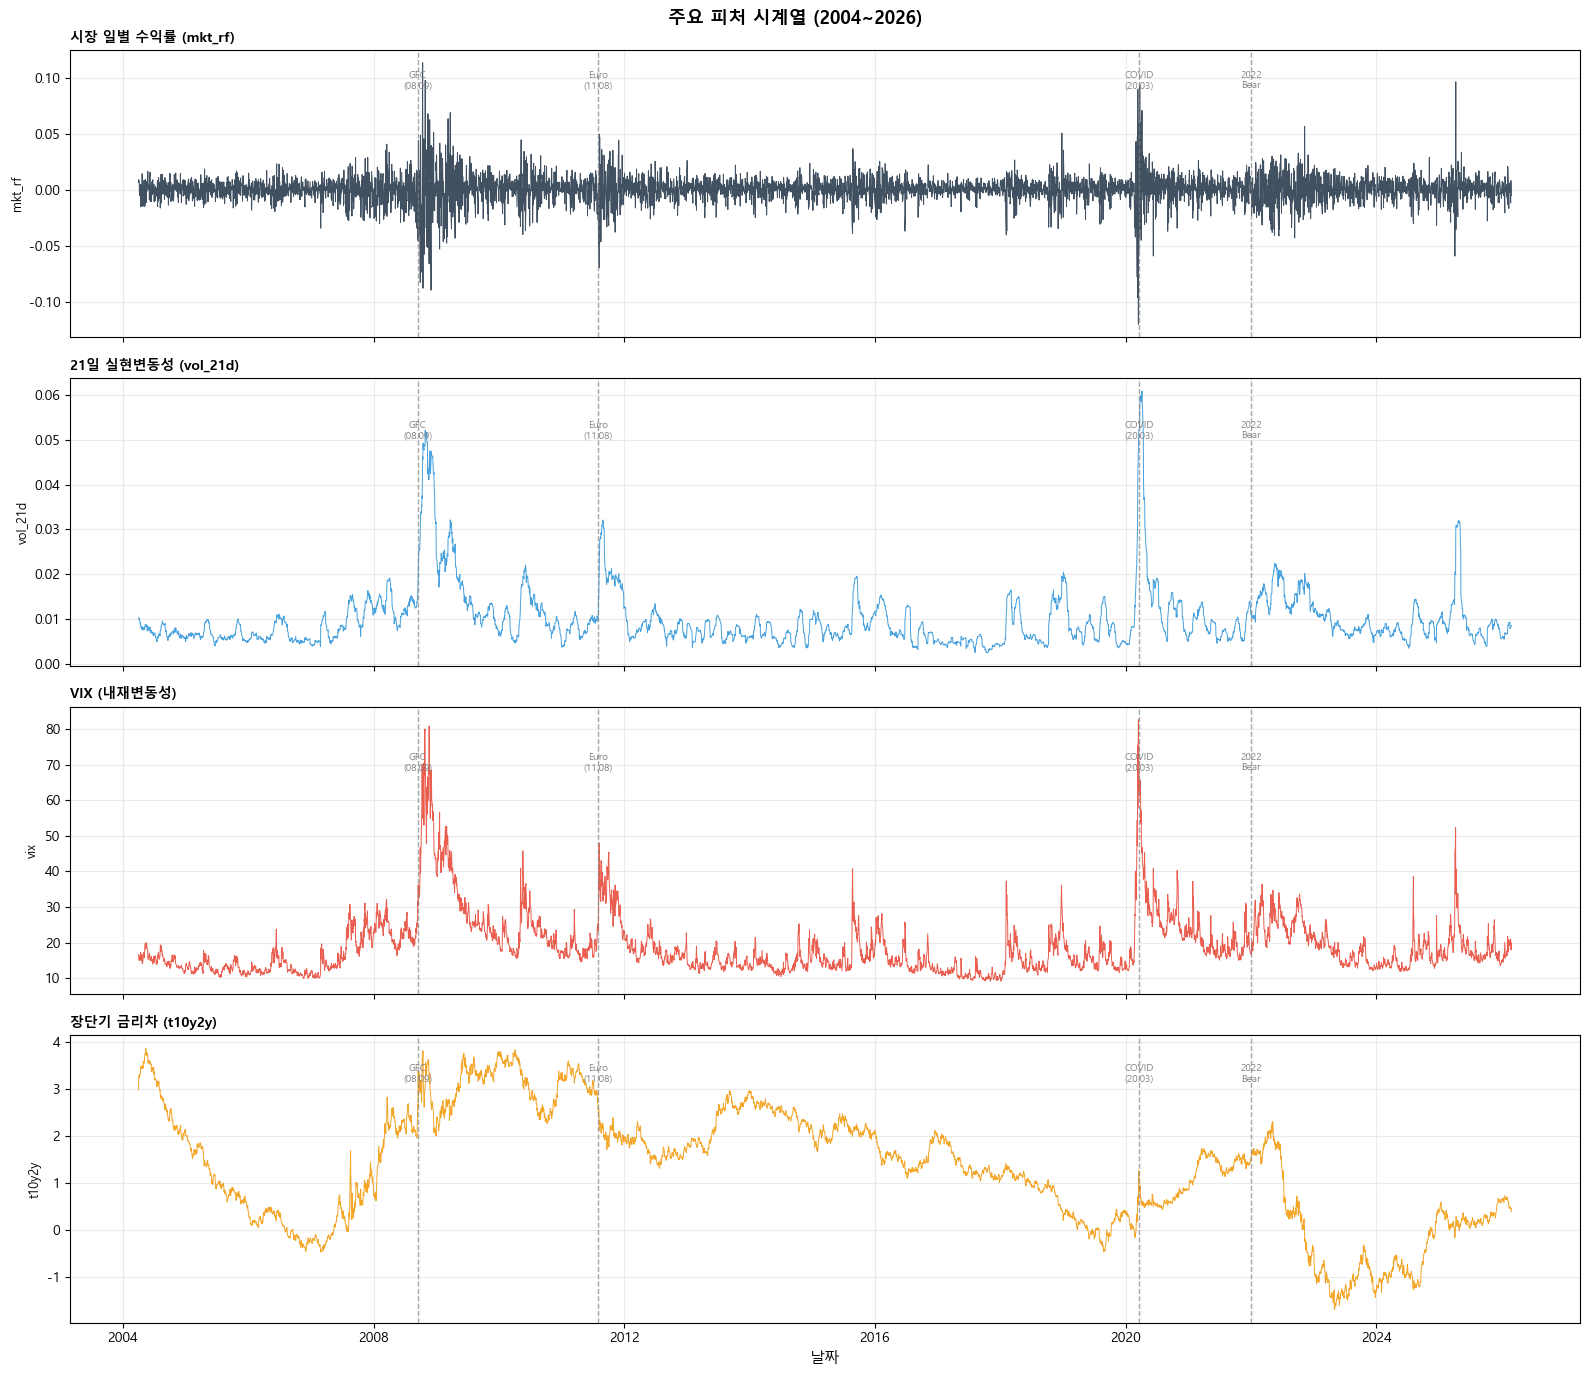

In [8]:
# ── 주요 피처 시계열 시각화 ────────────────────────────────────────────────────
EVENTS = {
    "GFC\n(08.09)": "2008-09-15",
    "Euro\n(11.08)": "2011-08-01",
    "COVID\n(20.03)": "2020-03-20",
    "2022\nBear":   "2022-01-01",
}

plot_series = [
    ("mkt_rf",   "시장 일별 수익률 (mkt_rf)",      "#2c3e50"),
    ("vol_21d",  "21일 실현변동성 (vol_21d)",      "#3498db"),
    ("vix",      "VIX (내재변동성)",               "#e74c3c"),
    ("t10y2y",   "장단기 금리차 (t10y2y)",         "#f39c12"),
]

fig, axes = plt.subplots(len(plot_series), 1, figsize=(16, 14), sharex=True)

for ax, (col, title, color) in zip(axes, plot_series):
    if col not in feat_df.columns:
        ax.set_visible(False)
        continue
    ax.plot(feat_df.index, feat_df[col], color=color, lw=0.7, alpha=0.9)
    ax.set_ylabel(col, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax.grid(alpha=0.25)
    for label, date_str in EVENTS.items():
        try:
            dt = pd.Timestamp(date_str)
            if feat_df.index[0] <= dt <= feat_df.index[-1]:
                ax.axvline(dt, color="gray", lw=1.0, linestyle="--", alpha=0.7)
                ax.text(dt, ax.get_ylim()[1] * 0.85, label,
                        fontsize=7, color="gray", ha="center", va="top")
        except Exception:
            pass

axes[-1].set_xlabel("날짜", fontsize=11)
plt.suptitle("주요 피처 시계열 (2004~2026)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "EDA_feature_timeseries.png", bbox_inches="tight")
plt.show()

## 5. n=3, 4, 5 레짐 비교 분석

세 가지 레짐 수에 대해 HMM을 각각 학습하고 결과를 비교합니다.

| 비교 항목 | 설명 |
|-----------|------|
| BIC / logL | 모델 적합도 비교 |
| 타임라인 | 레짐 구간별 시장 국면 |
| 레짐 통계 | 수익률·변동성·VIX |
| 전이 행렬 | 레짐 간 이동 확률 |
| KDE 분포 | 피처별 레짐 분포 |

In [38]:
PALETTE = {
    "Bull (강세)"      : "#2ecc71",
    "Mild Bull (완만)" : "#27ae60",
    "Recovery (회복)"  : "#3498db",
    "Neutral (중립)"   : "#f39c12",
    "Volatile (고변동)": "#e67e22",
    "Bear (약세)"      : "#e74c3c",
    "Crisis (위기)"    : "#8e44ad",
}
DEFAULT_COLORS = ["#2ecc71","#3498db","#f39c12","#e74c3c","#9b59b6"]
NAME_MAP = {
    3: ["Bull (강세)", "Neutral (중립)", "Bear (약세)"],
    4: ["Bull (강세)", "Recovery (회복)", "Neutral (중립)", "Bear (약세)"],
    5: ["Bull (강세)", "Mild Bull (완만)", "Neutral (중립)", "Volatile (고변동)", "Crisis (위기)"],
}

def get_color(label, idx=0):
    return PALETTE.get(label, DEFAULT_COLORS[idx % len(DEFAULT_COLORS)])

def _hmm_param_count(n, d):
    """GaussianHMM(full covariance) 실제 파라미터 수
    초기확률(n-1) + 전이행렬(n*(n-1)) + 평균(n*d) + 공분산full(n*d*(d+1)/2)
    """
    return (n - 1) + n * (n - 1) + n * d + n * d * (d + 1) // 2

def fit_hmm(n, X, feat_df, seed=SEED):
    d     = X.shape[1]
    T     = len(X)
    model = GaussianHMM(n_components=n, covariance_type="full", n_iter=500, random_state=seed)
    model.fit(X)
    logL      = model.score(X)          # per-sample log-likelihood
    k         = _hmm_param_count(n, d)
    bic       = k * np.log(T) - 2 * logL * T
    states    = model.predict(X)
    posterior = model.predict_proba(X)

    regime_stats = []
    for s in range(n):
        mask = (states == s)
        regime_stats.append({
            "state"    : s,
            "count"    : mask.sum(),
            "pct"      : 100 * mask.sum() / len(states),
            "mean_ret" : feat_df.loc[mask, "mkt_rf"].mean(),
            "mean_vol" : feat_df.loc[mask, "vol_21d"].mean(),
            "mean_vix" : feat_df.loc[mask, "vix"].mean(),
        })
    stats = pd.DataFrame(regime_stats).sort_values("mean_vix", ascending=True).reset_index(drop=True)
    names = NAME_MAP.get(n, [f"Regime {i}" for i in range(n)])
    state_to_label = {}
    for rank, row in stats.iterrows():
        lbl = names[rank] if rank < len(names) else f"Regime {rank}"
        state_to_label[int(row["state"])] = lbl
        stats.loc[rank, "label"] = lbl

    return dict(model=model, states=states, posterior=posterior,
                stats=stats, state_to_label=state_to_label, bic=bic, logL=logL, k=k)

# n=3,4,5 학습
results = {}
print(f"{'n':>3}  {'d':>3}  {'k(파라미터수)':>14}  {'logL':>14}  {'BIC':>22}  수렴")
print("-" * 72)
for n in [3, 4, 5]:
    r = fit_hmm(n, X_scaled, feat_df)
    results[n] = r
    print(f"  {n}  {X_scaled.shape[1]:>3}  {r['k']:>14d}  {r['logL']:>14.2f}  {r['bic']:>22.1f}  {r['model'].monitor_.converged}")

best_n = min(results, key=lambda n: results[n]["bic"])
dates  = feat_df.index
print(f"\n→ BIC 최적 n = {best_n}")

  n    d        k(파라미터수)            logL                     BIC  수렴
------------------------------------------------------------------------
  3   16             464       -73493.09             810191784.3  True
  4   16             623       -70302.73             775022631.2  True
  5   16             784       -68356.66             753570578.4  True

→ BIC 최적 n = 5


## 피처 적절성 검증

레짐 구분에 실제로 기여하는 피처인지 4가지 방법으로 확인합니다.

| 검증 방법 | 판단 기준 |
|-----------|-----------|
| **상관 행렬 & VIF** | VIF > 10이면 다중공선성 심각, 5~10이면 주의 |
| **Kruskal-Wallis 검정** | p < 0.05이면 레짐 간 분포 차이 유의 |
| **HMM 평균 분산** | 레짐별 평균의 std가 클수록 분리력 높음 |
| **Ablation (제거 실험)** | ΔBIC > 0이면 해당 피처가 모델에 기여 |

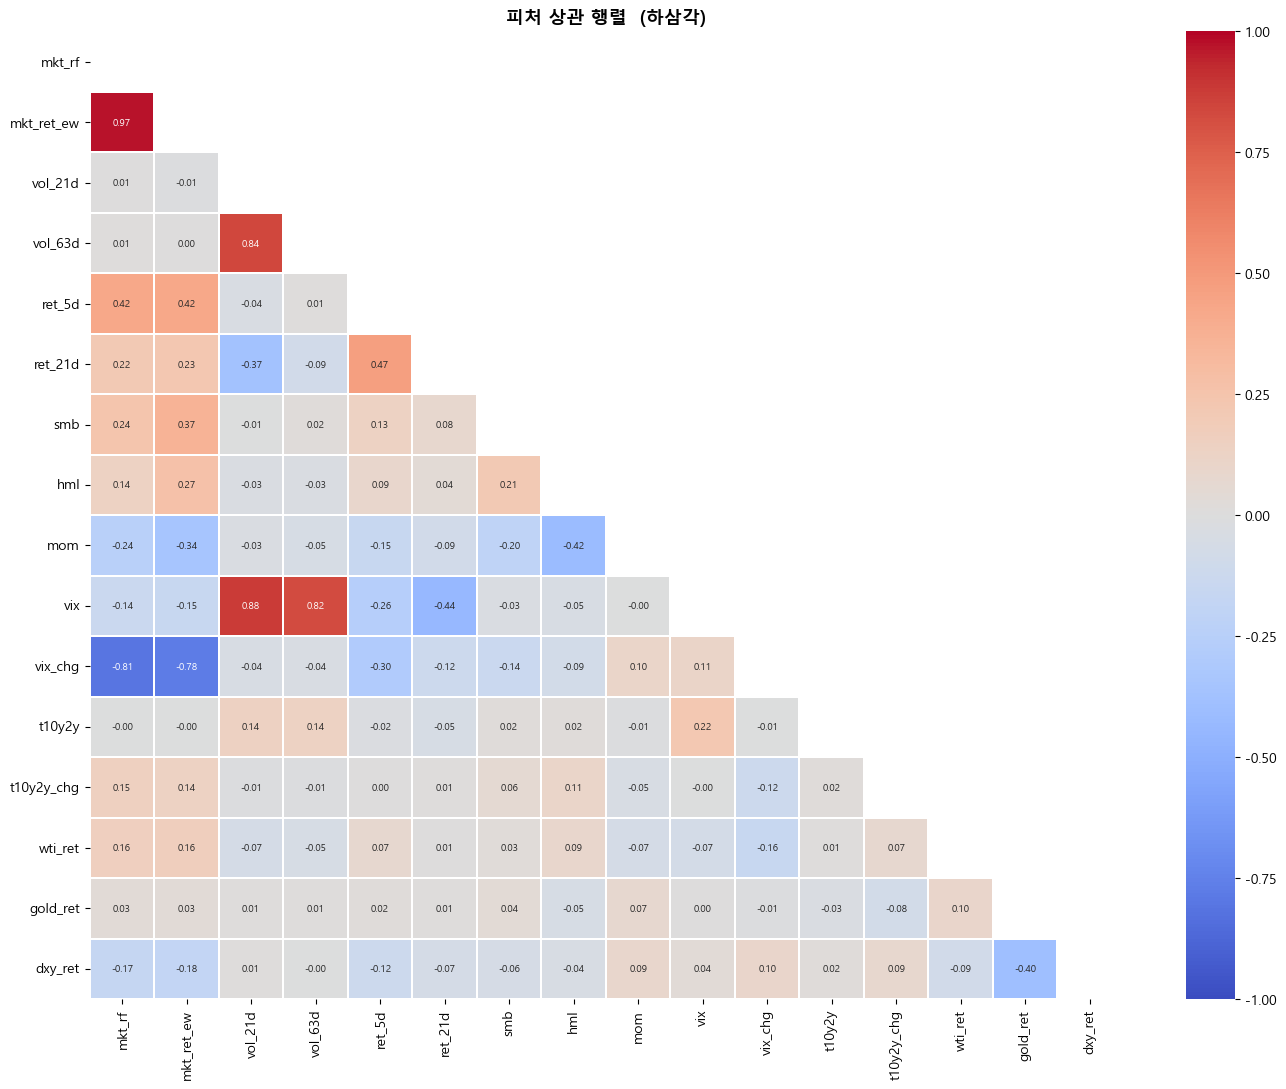

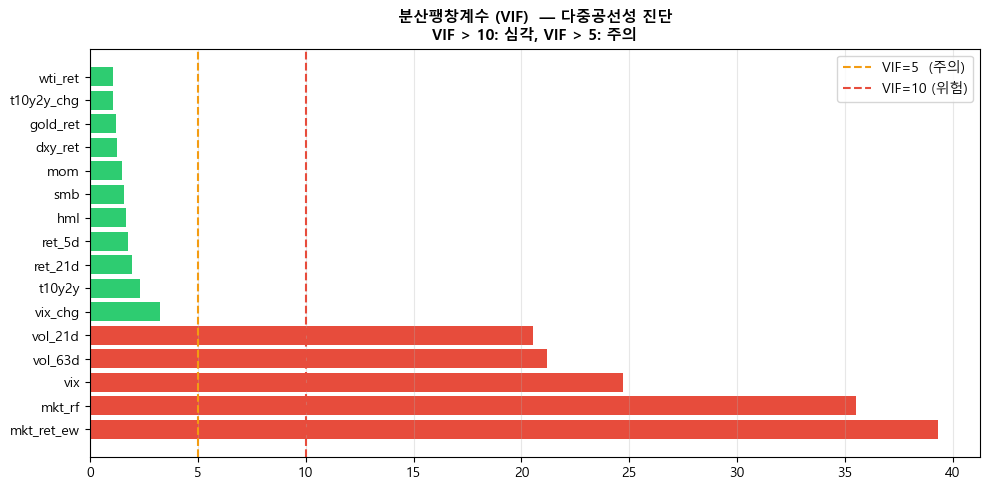

   feature       VIF
mkt_ret_ew 39.286161
    mkt_rf 35.516720
       vix 24.694893
   vol_63d 21.180106
   vol_21d 20.547122
   vix_chg  3.227852
    t10y2y  2.307280
   ret_21d  1.935843
    ret_5d  1.768885
       hml  1.657479
       smb  1.602818
       mom  1.468777
   dxy_ret  1.252823
  gold_ret  1.222673
t10y2y_chg  1.069375
   wti_ret  1.062176


In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── 상관 행렬 ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
corr = feat_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.3, ax=ax, annot_kws={"size": 7},
            vmin=-1, vmax=1)
ax.set_title("피처 상관 행렬  (하삼각)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "V1_correlation_matrix.png", bbox_inches="tight")
plt.show()

# ── VIF ──────────────────────────────────────────────────────────────────────
vif_vals = [variance_inflation_factor(feat_df.values, i)
            for i in range(feat_df.shape[1])]
vif_df = (pd.DataFrame({"feature": feat_df.columns, "VIF": vif_vals})
            .sort_values("VIF", ascending=False)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 5))
vcolors = ["#e74c3c" if v > 10 else "#f39c12" if v > 5 else "#2ecc71"
           for v in vif_df["VIF"]]
ax.barh(vif_df["feature"], vif_df["VIF"], color=vcolors)
ax.axvline(5,  color="#f39c12", linestyle="--", lw=1.5, label="VIF=5  (주의)")
ax.axvline(10, color="#e74c3c", linestyle="--", lw=1.5, label="VIF=10 (위험)")
ax.set_title("분산팽창계수 (VIF)  — 다중공선성 진단\nVIF > 10: 심각, VIF > 5: 주의",
             fontweight="bold", fontsize=11)
ax.legend(); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "V2_vif.png", bbox_inches="tight")
plt.show()

print(vif_df.to_string(index=False))

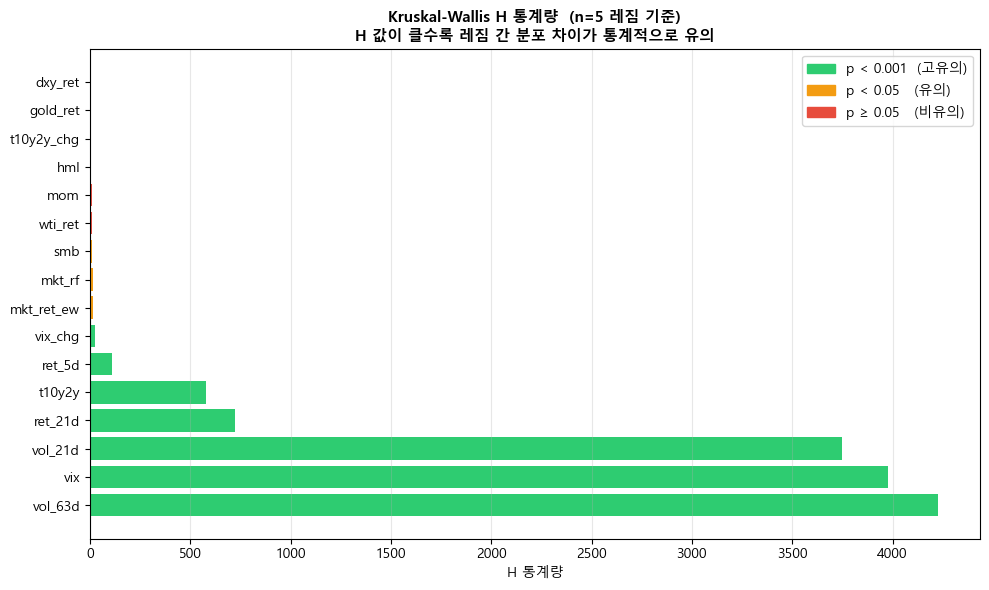

   feature    H_stat   p_KW    F_stat  p_ANOVA 유의
   vol_63d 4224.4249 0.0000 3593.7606   0.0000  ✅
       vix 3979.6809 0.0000 3838.7270   0.0000  ✅
   vol_21d 3747.6995 0.0000 3149.1623   0.0000  ✅
   ret_21d  722.9954 0.0000  225.5790   0.0000  ✅
    t10y2y  576.3979 0.0000  173.7359   0.0000  ✅
    ret_5d  110.5741 0.0000   37.2694   0.0000  ✅
   vix_chg   26.1475 0.0000    1.6211   0.1660  ✅
mkt_ret_ew   17.4842 0.0016    5.9439   0.0001  ✅
    mkt_rf   16.8696 0.0020    4.8686   0.0006  ✅
       smb   11.1715 0.0247    2.1169   0.0760  ✅
   wti_ret    9.2924 0.0542    5.8594   0.0001  ❌
       mom    8.6940 0.0692    5.3313   0.0003  ❌
       hml    7.7287 0.1020    0.3650   0.8337  ❌
t10y2y_chg    6.6970 0.1528    2.5063   0.0401  ❌
  gold_ret    6.2313 0.1825    0.7065   0.5874  ❌
   dxy_ret    4.7732 0.3114    1.1121   0.3488  ❌


In [40]:
from scipy import stats as sp_stats

# best_n 모델의 레짐 레이블
regime_labels = np.array([results[best_n]["state_to_label"][s]
                           for s in results[best_n]["states"]])
feat_labeled  = feat_df.copy()
feat_labeled["regime"] = regime_labels

# ── Kruskal-Wallis + One-way ANOVA ───────────────────────────────────────────
kw_results = []
for col in feat_df.columns:
    groups   = [g[col].values for _, g in feat_labeled.groupby("regime")]
    f_stat, p_anova = sp_stats.f_oneway(*groups)
    h_stat, p_kw    = sp_stats.kruskal(*groups)
    kw_results.append({
        "feature": col,
        "H_stat" : h_stat, "p_KW"  : p_kw,
        "F_stat" : f_stat, "p_ANOVA": p_anova,
        "유의"   : "✅" if p_kw < 0.05 else "❌",
    })

kw_df = (pd.DataFrame(kw_results)
           .sort_values("H_stat", ascending=False)
           .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ["#2ecc71" if p < 0.001 else "#f39c12" if p < 0.05 else "#e74c3c"
              for p in kw_df["p_KW"]]
ax.barh(kw_df["feature"], kw_df["H_stat"], color=bar_colors)
ax.set_title(f"Kruskal-Wallis H 통계량  (n={best_n} 레짐 기준)\n"
             "H 값이 클수록 레짐 간 분포 차이가 통계적으로 유의",
             fontweight="bold", fontsize=11)
ax.set_xlabel("H 통계량")
ax.grid(axis="x", alpha=0.3)
p1 = mpatches.Patch(color="#2ecc71", label="p < 0.001  (고유의)")
p2 = mpatches.Patch(color="#f39c12", label="p < 0.05   (유의)")
p3 = mpatches.Patch(color="#e74c3c", label="p ≥ 0.05   (비유의)")
ax.legend(handles=[p1, p2, p3])
plt.tight_layout()
plt.savefig(OUT_DIR / "V3_kruskal_wallis.png", bbox_inches="tight")
plt.show()

print(kw_df[["feature","H_stat","p_KW","F_stat","p_ANOVA","유의"]]
      .round(4).to_string(index=False))

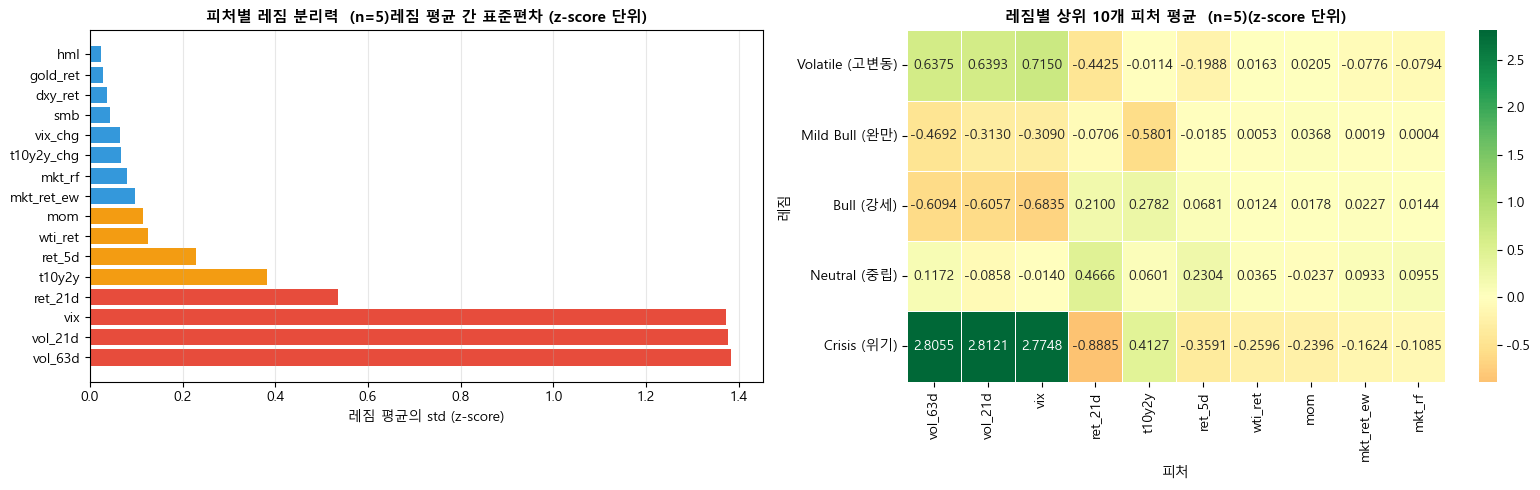

레짐 분리력 순위 (z-score 기준):
   1. vol_63d          std=1.38298  🔴 HIGH
   2. vol_21d          std=1.37765  🔴 HIGH
   3. vix              std=1.37299  🔴 HIGH
   4. ret_21d          std=0.53547  🔴 HIGH
   5. t10y2y           std=0.38173  🟡 MID 
   6. ret_5d           std=0.22974  🟡 MID 
   7. wti_ret          std=0.12453  🟡 MID 
   8. mom              std=0.11510  🟡 MID 
   9. mkt_ret_ew       std=0.09826  🔵 LOW 
  10. mkt_rf           std=0.08095  🔵 LOW 
  11. t10y2y_chg       std=0.06619  🔵 LOW 
  12. vix_chg          std=0.06482  🔵 LOW 
  13. smb              std=0.04340  🔵 LOW 
  14. dxy_ret          std=0.03622  🔵 LOW 
  15. gold_ret         std=0.02864  🔵 LOW 
  16. hml              std=0.02447  🔵 LOW 


In [41]:
# ── HMM 평균 벡터 기반 피처 중요도 ──────────────────────────────────────────
best_model = results[best_n]["model"]

# 스케일된 공간에서 계산 (z-score 단위) — 원 스케일 역변환 시 VIX 단위가 크게 나와 왜곡됨
means_df = pd.DataFrame(
    best_model.means_,
    columns=feat_df.columns,
    index=[results[best_n]["state_to_label"][i] for i in range(best_n)]
)

# 레짐 간 평균의 표준편차 → 피처별 분리력 (z-score 단위로 공정 비교)
importance = means_df.std(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_imp = ["#e74c3c" if v >= importance.quantile(0.75)
              else "#f39c12" if v >= importance.quantile(0.5)
              else "#3498db" for v in importance]
axes[0].barh(importance.index, importance.values, color=colors_imp)
axes[0].set_title(f"피처별 레짐 분리력  (n={best_n})레짐 평균 간 표준편차 (z-score 단위)",
                  fontweight="bold", fontsize=11)
axes[0].set_xlabel("레짐 평균의 std (z-score)")
axes[0].grid(axis="x", alpha=0.3)

top10 = importance.index[:10].tolist()
sns.heatmap(means_df[top10], annot=True, fmt=".4f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=axes[1])
axes[1].set_title(f"레짐별 상위 10개 피처 평균  (n={best_n})(z-score 단위)", fontweight="bold", fontsize=11)
axes[1].set_xlabel("피처"); axes[1].set_ylabel("레짐")

plt.tight_layout()
plt.savefig(OUT_DIR / "V4_feature_importance.png", bbox_inches="tight")
plt.show()

print("레짐 분리력 순위 (z-score 기준):")
for rank, (feat_name, val) in enumerate(importance.items(), 1):
    tier = "🔴 HIGH" if val >= importance.quantile(0.75) else            "🟡 MID " if val >= importance.quantile(0.5) else "🔵 LOW "
    print(f"  {rank:>2}. {feat_name:<15}  std={val:.5f}  {tier}")

기준 BIC (전체 16개 피처, n=5, k=784): 753570578.4

피처                                제거 후 BIC            ΔBIC  기여도
--------------------------------------------------------------------
  mkt_rf                       783627206.1     +30056627.8  🔴 핵심
  mkt_ret_ew                   805202033.0     +51631454.6  🔴 핵심
  vol_21d                      764323276.1     +10752697.7  🔴 핵심
  vol_63d                      762934657.3      +9364078.9  🔴 핵심
  ret_5d                       696244682.7     -57325895.7  🔵 미미
  ret_21d                      720562963.2     -33007615.1  🔵 미미
  smb                          685023734.6     -68546843.8  🔵 미미
  hml                          710662259.5     -42908318.9  🔵 미미
  mom                          708098448.4     -45472130.0  🔵 미미
  vix                          767885743.8     +14315165.5  🔴 핵심
  vix_chg                      740932168.0     -12638410.4  🔵 미미
  t10y2y                       693171618.9     -60398959.5  🔵 미미
  t10y2y_chg                   695542028.1

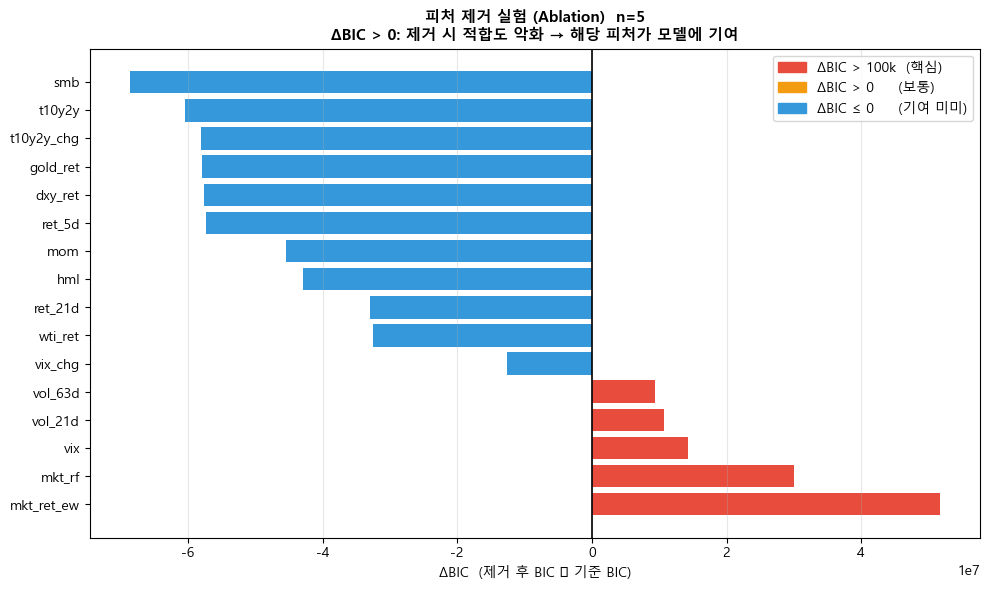

In [42]:
# ── Ablation: 피처 하나씩 제거 시 BIC 변화 ───────────────────────────────────
base_bic = results[best_n]["bic"]
ablation_results = []

print(f"기준 BIC (전체 {feat_df.shape[1]}개 피처, n={best_n}, k={results[best_n]['k']}): {base_bic:.1f}\n")
print(f"{'피처':<18}  {'제거 후 BIC':>22}  {'ΔBIC':>14}  기여도")
print("-" * 68)

for col in feat_df.columns:
    cols_sub = [c for c in feat_df.columns if c != col]
    X_sub    = StandardScaler().fit_transform(feat_df[cols_sub].values)
    d_sub    = X_sub.shape[1]
    k_sub    = _hmm_param_count(best_n, d_sub)
    m_abl    = GaussianHMM(n_components=best_n, covariance_type="full",
                           n_iter=200, random_state=SEED)
    m_abl.fit(X_sub)
    bic_sub  = k_sub * np.log(len(X_sub)) - 2 * m_abl.score(X_sub) * len(X_sub)
    delta    = bic_sub - base_bic
    tier     = "🔴 핵심" if delta > 1e5 else "🟡 보통" if delta > 0 else "🔵 미미"
    ablation_results.append({"feature": col, "BIC_without": bic_sub, "delta_BIC": delta})
    print(f"  {col:<16}  {bic_sub:>22.1f}  {delta:>+14.1f}  {tier}")

abl_df = (pd.DataFrame(ablation_results)
            .sort_values("delta_BIC", ascending=False)
            .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if d > 1e5 else "#f39c12" if d > 0 else "#3498db"
          for d in abl_df["delta_BIC"]]
ax.barh(abl_df["feature"], abl_df["delta_BIC"], color=colors)
ax.axvline(0, color="black", lw=1.2)
ax.set_title(f"피처 제거 실험 (Ablation)  n={best_n}\n"
             "ΔBIC > 0: 제거 시 적합도 악화 → 해당 피처가 모델에 기여",
             fontweight="bold", fontsize=11)
ax.set_xlabel("ΔBIC  (제거 후 BIC − 기준 BIC)")
p1 = mpatches.Patch(color="#e74c3c", label="ΔBIC > 100k  (핵심)")
p2 = mpatches.Patch(color="#f39c12", label="ΔBIC > 0     (보통)")
p3 = mpatches.Patch(color="#3498db", label="ΔBIC ≤ 0     (기여 미미)")
ax.legend(handles=[p1, p2, p3]); ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "V5_ablation.png", bbox_inches="tight")
plt.show()

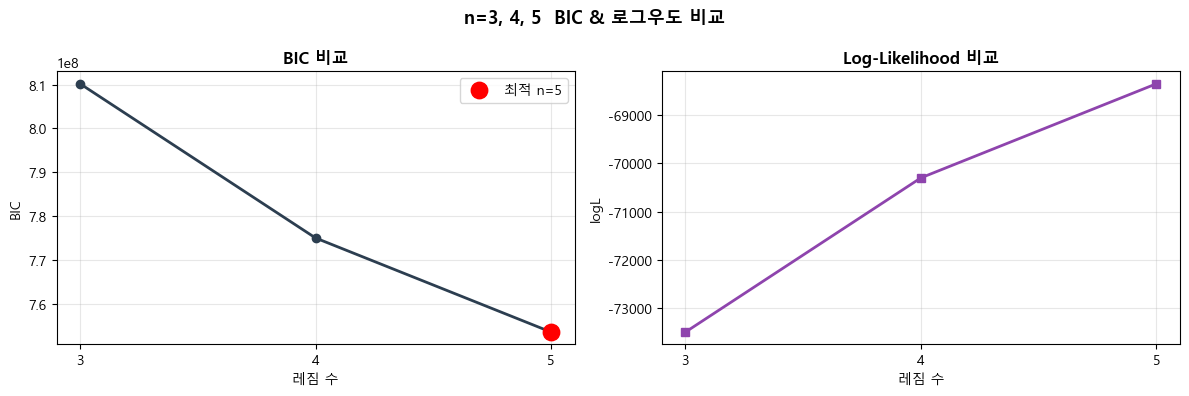

In [43]:
ns   = [3, 4, 5]
bics = [results[n]["bic"]  for n in ns]
lgls = [results[n]["logL"] for n in ns]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ns, bics, marker="o", color="#2c3e50", lw=2)
axes[0].scatter([best_n], [results[best_n]["bic"]], color="red", s=140, zorder=5,
                label=f"최적 n={best_n}")
axes[0].set_title("BIC 비교", fontweight="bold", fontsize=12)
axes[0].set_xlabel("레짐 수"); axes[0].set_ylabel("BIC")
axes[0].set_xticks(ns); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ns, lgls, marker="s", color="#8e44ad", lw=2)
axes[1].set_title("Log-Likelihood 비교", fontweight="bold", fontsize=12)
axes[1].set_xlabel("레짐 수"); axes[1].set_ylabel("logL")
axes[1].set_xticks(ns); axes[1].grid(alpha=0.3)

plt.suptitle("n=3, 4, 5  BIC & 로그우도 비교", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_bic_comparison.png", bbox_inches="tight")
plt.show()

## 6. 타임라인 비교 (n=3, 4, 5)

레짐 수별로 시장 국면이 어떻게 구분되는지 누적 수익률 위에 겹쳐 비교합니다.

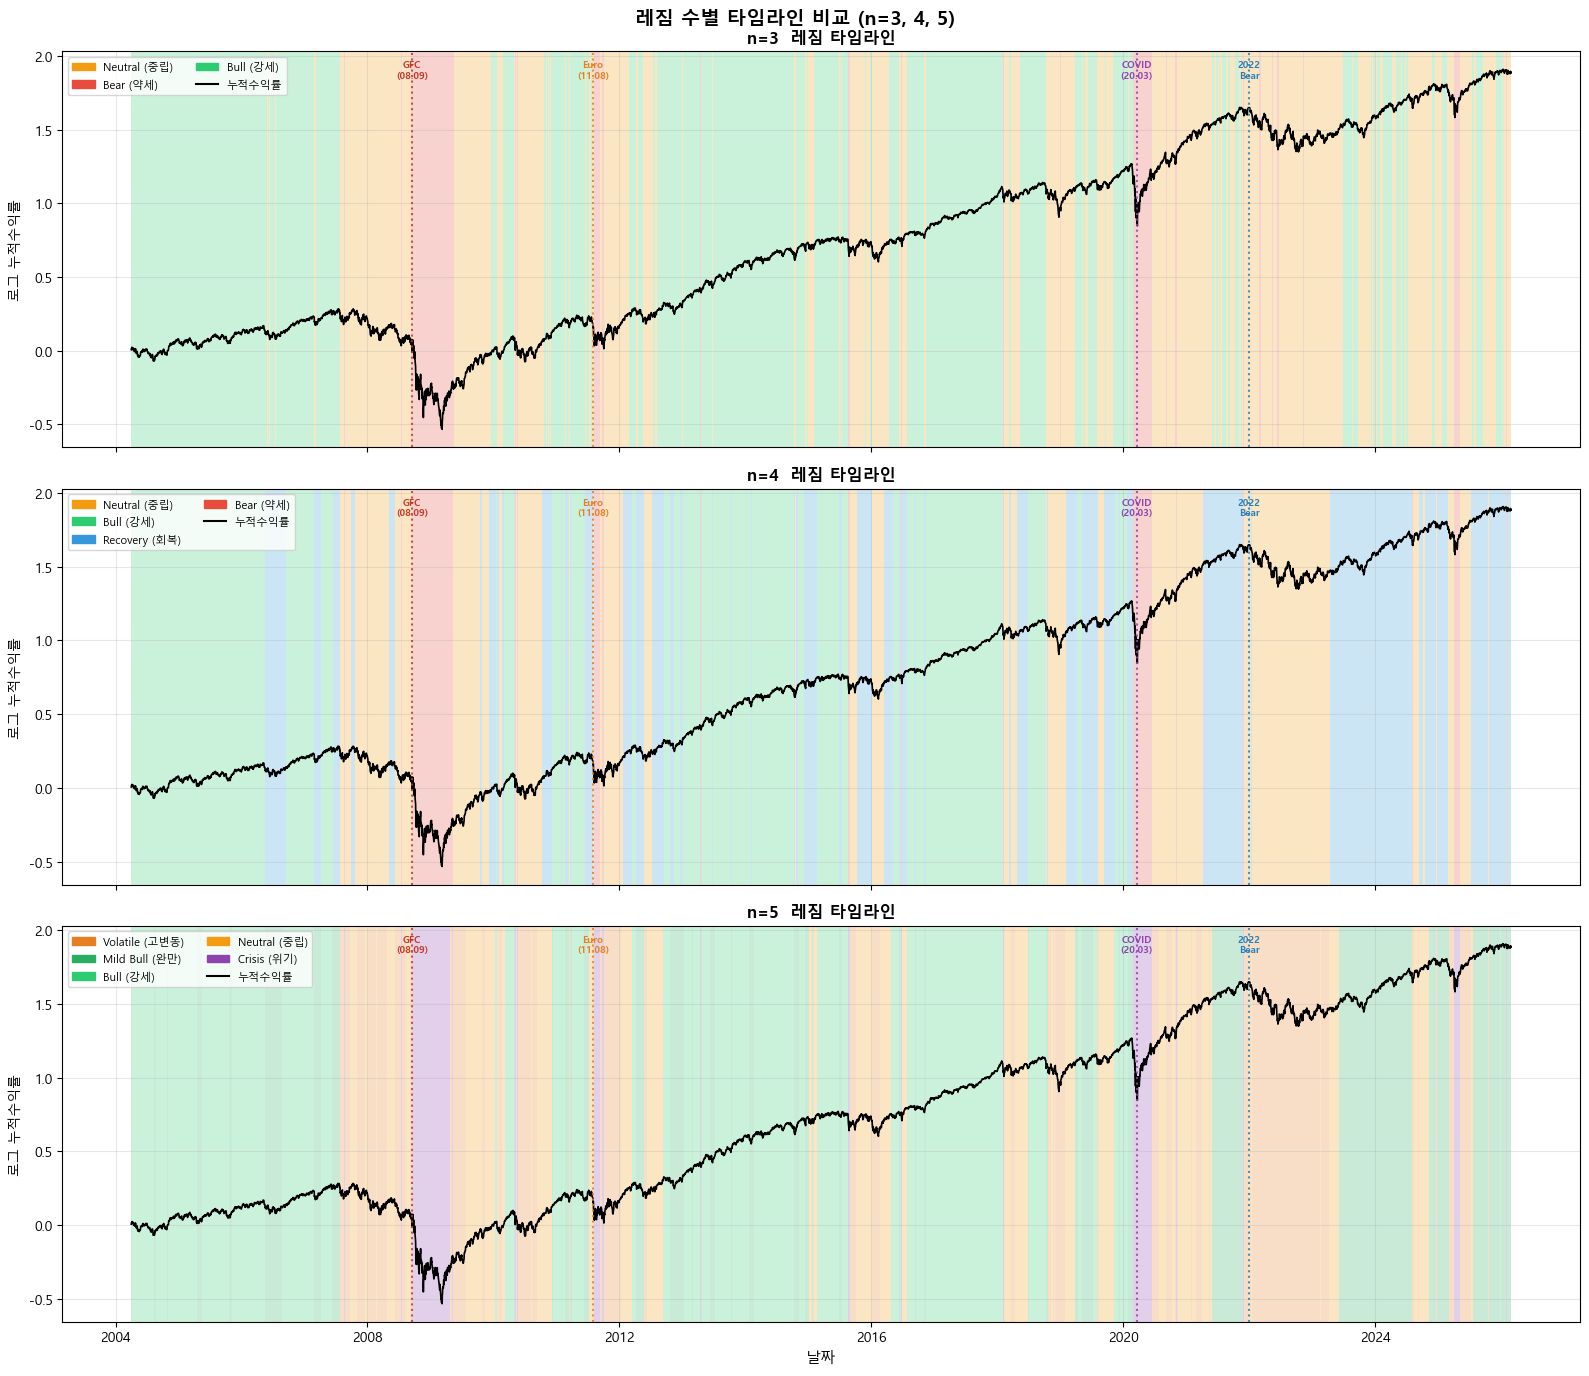

In [44]:
mkt_cum = (1 + feat_df["mkt_rf"]).cumprod().apply(np.log)

EVENTS = {
    "GFC\n(08.09)": ("2008-09-15", "#c0392b"),
    "Euro\n(11.08)": ("2011-08-01", "#e67e22"),
    "COVID\n(20.03)": ("2020-03-20", "#8e44ad"),
    "2022\nBear": ("2022-01-01", "#2980b9"),
}

fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, n in zip(axes, [3, 4, 5]):
    r   = results[n]
    st  = r["states"]
    s2l = r["state_to_label"]
    uq  = sorted(s2l.keys())

    ax.plot(dates, mkt_cum.values, color="black", lw=1.2)

    prev_s = st[0]; t0 = dates[0]
    for i in range(1, len(st)):
        if st[i] != prev_s or i == len(st) - 1:
            lbl = s2l[prev_s]
            ax.axvspan(t0, dates[i], alpha=0.25, color=get_color(lbl, uq.index(prev_s)), lw=0)
            prev_s = st[i]; t0 = dates[i]

    # ── 주요 사건 마커 ──────────────────────────────────────────────────────
    y_min, y_max = ax.get_ylim()
    for label, (date_str, ecolor) in EVENTS.items():
        dt = pd.Timestamp(date_str)
        if dates[0] <= dt <= dates[-1]:
            ax.axvline(dt, color=ecolor, lw=1.5, linestyle=":", alpha=0.85, zorder=5)
            ax.text(dt, y_max * 0.97, label, fontsize=7, color=ecolor,
                    ha="center", va="top", fontweight="bold")

    patches = [mpatches.Patch(color=get_color(s2l[s], uq.index(s)), label=s2l[s]) for s in uq]
    ax.legend(handles=patches + [plt.Line2D([0],[0], color="black", lw=1.5, label="누적수익률")],
              loc="upper left", fontsize=8, ncol=2)
    ax.set_ylabel("로그 누적수익률")
    ax.set_title(f"n={n}  레짐 타임라인", fontweight="bold", fontsize=12)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("날짜", fontsize=11)
plt.suptitle("레짐 수별 타임라인 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "02_timeline_comparison.png", bbox_inches="tight")
plt.show()

## 7. 레짐 통계 비교 (n=3, 4, 5)

In [45]:
print("=" * 72)
print("   레짐 수별 통계 비교")
print("=" * 72)
print(f"분석 기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}   총 거래일: {len(feat_df):,}일\n")

for n in [3, 4, 5]:
    r = results[n]
    mark = " ◀ BIC 최적" if n == best_n else ""
    print(f"── n={n}  (BIC={r['bic']:.0f},  logL={r['logL']:.2f},  수렴={r['model'].monitor_.converged}){mark}")
    for _, row in r["stats"].iterrows():
        print(f"  [{row['label']:<16}]  {row['pct']:5.1f}%  ({int(row['count']):4d}일)  "
              f"수익={row['mean_ret']*100:+.3f}%  "
              f"변동={row['mean_vol']*100:.3f}%  "
              f"VIX={row['mean_vix']:.1f}")
    print()

   레짐 수별 통계 비교
분석 기간: 2004-04-01 ~ 2026-02-27   총 거래일: 5,512일

── n=3  (BIC=810191784,  logL=-73493.09,  수렴=True)
  [Bull (강세)       ]   50.4%  (2777일)  수익=+0.077%  변동=0.658%  VIX=14.0
  [Neutral (중립)    ]   42.5%  (2344일)  수익=+0.029%  변동=1.138%  VIX=21.4
  [Bear (약세)       ]    7.1%  ( 391일)  수익=-0.132%  변동=2.694%  VIX=40.6

── n=4  (BIC=775022631,  logL=-70302.73,  수렴=True)
  [Bull (강세)       ]   36.0%  (1985일)  수익=+0.074%  변동=0.619%  VIX=13.4
  [Recovery (회복)   ]   31.2%  (1718일)  수익=+0.042%  변동=0.798%  VIX=16.6
  [Neutral (중립)    ]   26.6%  (1464일)  수익=+0.024%  변동=1.345%  VIX=24.0
  [Bear (약세)       ]    6.3%  ( 345일)  수익=-0.078%  변동=2.839%  VIX=42.0

── n=5  (BIC=753570578,  logL=-68356.66,  수렴=True) ◀ BIC 최적
  [Bull (강세)       ]   34.4%  (1894일)  수익=+0.057%  변동=0.597%  VIX=13.2
  [Mild Bull (완만)  ]   22.0%  (1210일)  수익=+0.047%  변동=0.795%  VIX=16.4
  [Neutral (중립)    ]   18.0%  ( 992일)  수익=+0.154%  변동=0.949%  VIX=18.9
  [Volatile (고변동)  ]   19.9%  (1095일)  수익=-0.060%  변동=1.440%  V

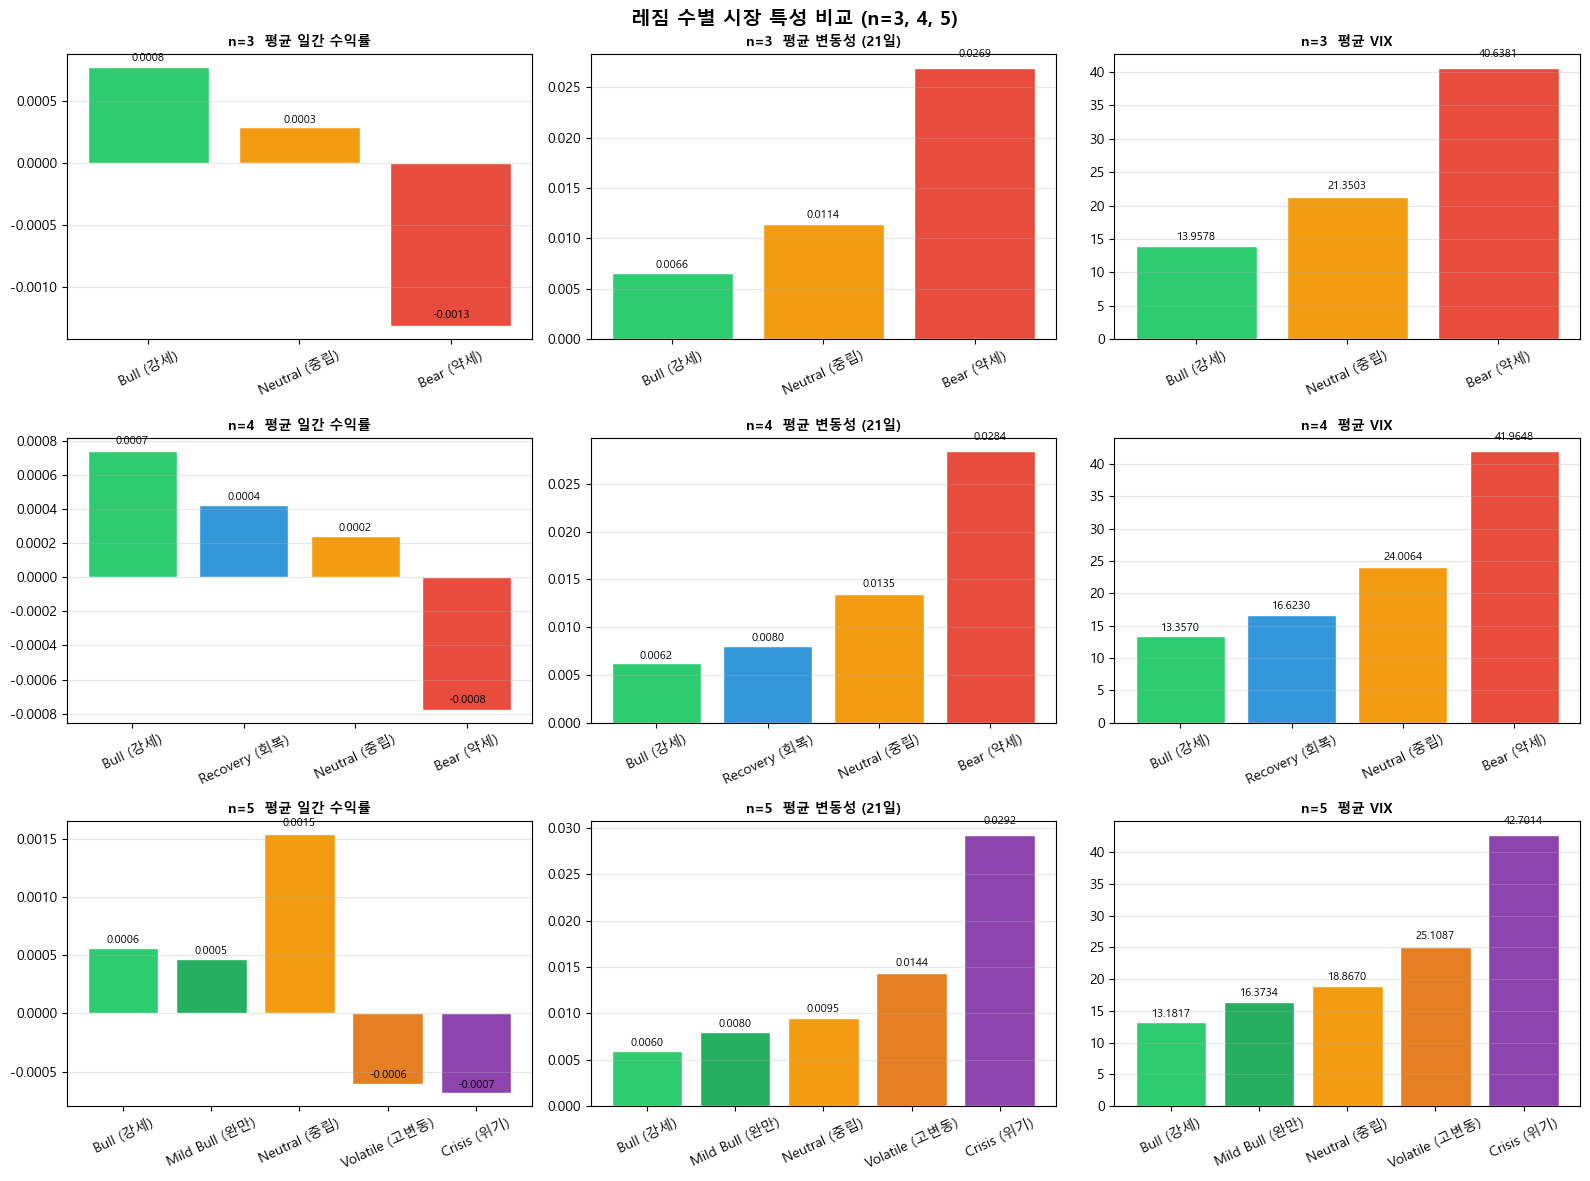

In [46]:
metrics = [("mean_ret", "평균 일간 수익률"), ("mean_vol", "평균 변동성 (21일)"), ("mean_vix", "평균 VIX")]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row_idx, n in enumerate([3, 4, 5]):
    r  = results[n]
    st = r["stats"]
    for col_idx, (col, title) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        colors = [get_color(row["label"], i) for i, row in st.iterrows()]
        bars   = ax.bar(st["label"], st[col], color=colors, edgecolor="white")
        ax.set_title(f"n={n}  {title}", fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, st[col]):
            if pd.notna(val):
                ypos = bar.get_height() + abs(bar.get_height()) * 0.03
                ax.text(bar.get_x() + bar.get_width()/2, ypos,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("레짐 수별 시장 특성 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "03_regime_stats_comparison.png", bbox_inches="tight")
plt.show()

## 8. 전이 행렬 비교 (n=3, 4, 5)

대각선 값이 높을수록 해당 레짐의 **지속성(persistence)**이 높습니다.

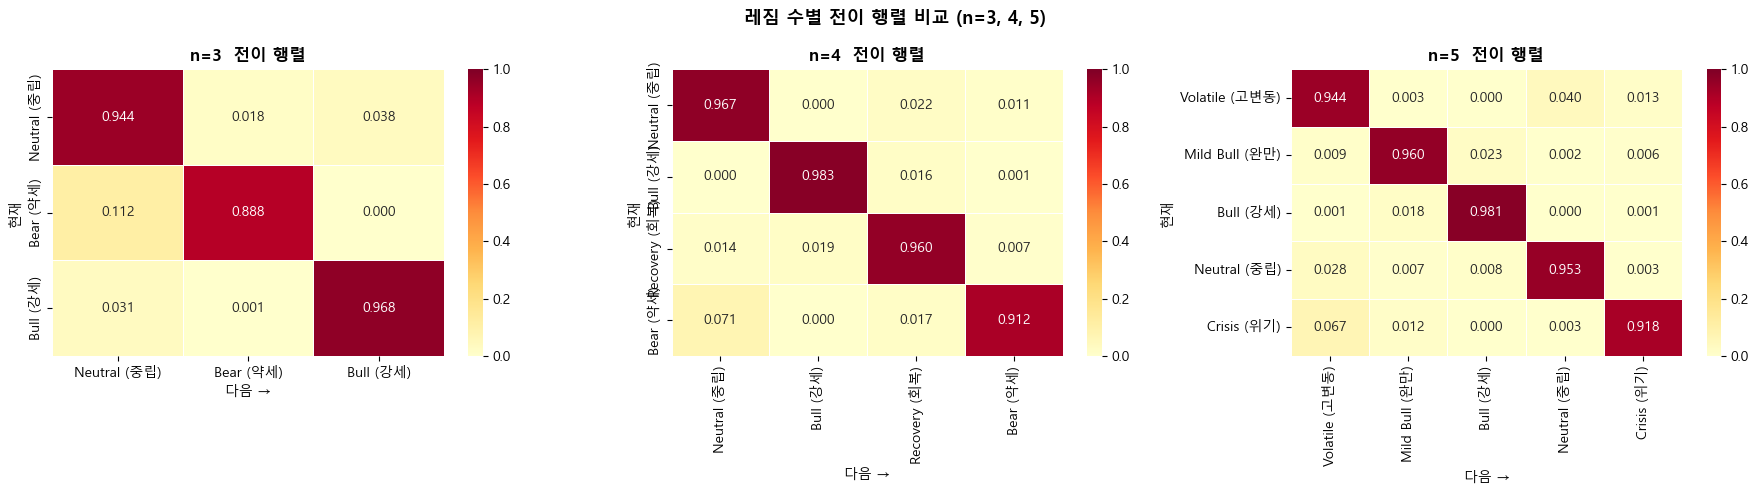

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, n in zip(axes, [3, 4, 5]):
    r        = results[n]
    labels   = [r["state_to_label"][i] for i in range(n)]
    trans_df = pd.DataFrame(r["model"].transmat_, index=labels, columns=labels)
    sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"n={n}  전이 행렬", fontweight="bold", fontsize=12)
    ax.set_xlabel("다음 →"); ax.set_ylabel("현재")

plt.suptitle("레짐 수별 전이 행렬 비교 (n=3, 4, 5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "04_transition_comparison.png", bbox_inches="tight")
plt.show()

## 9. 피처 분포 비교 (KDE, n=3, 4, 5)

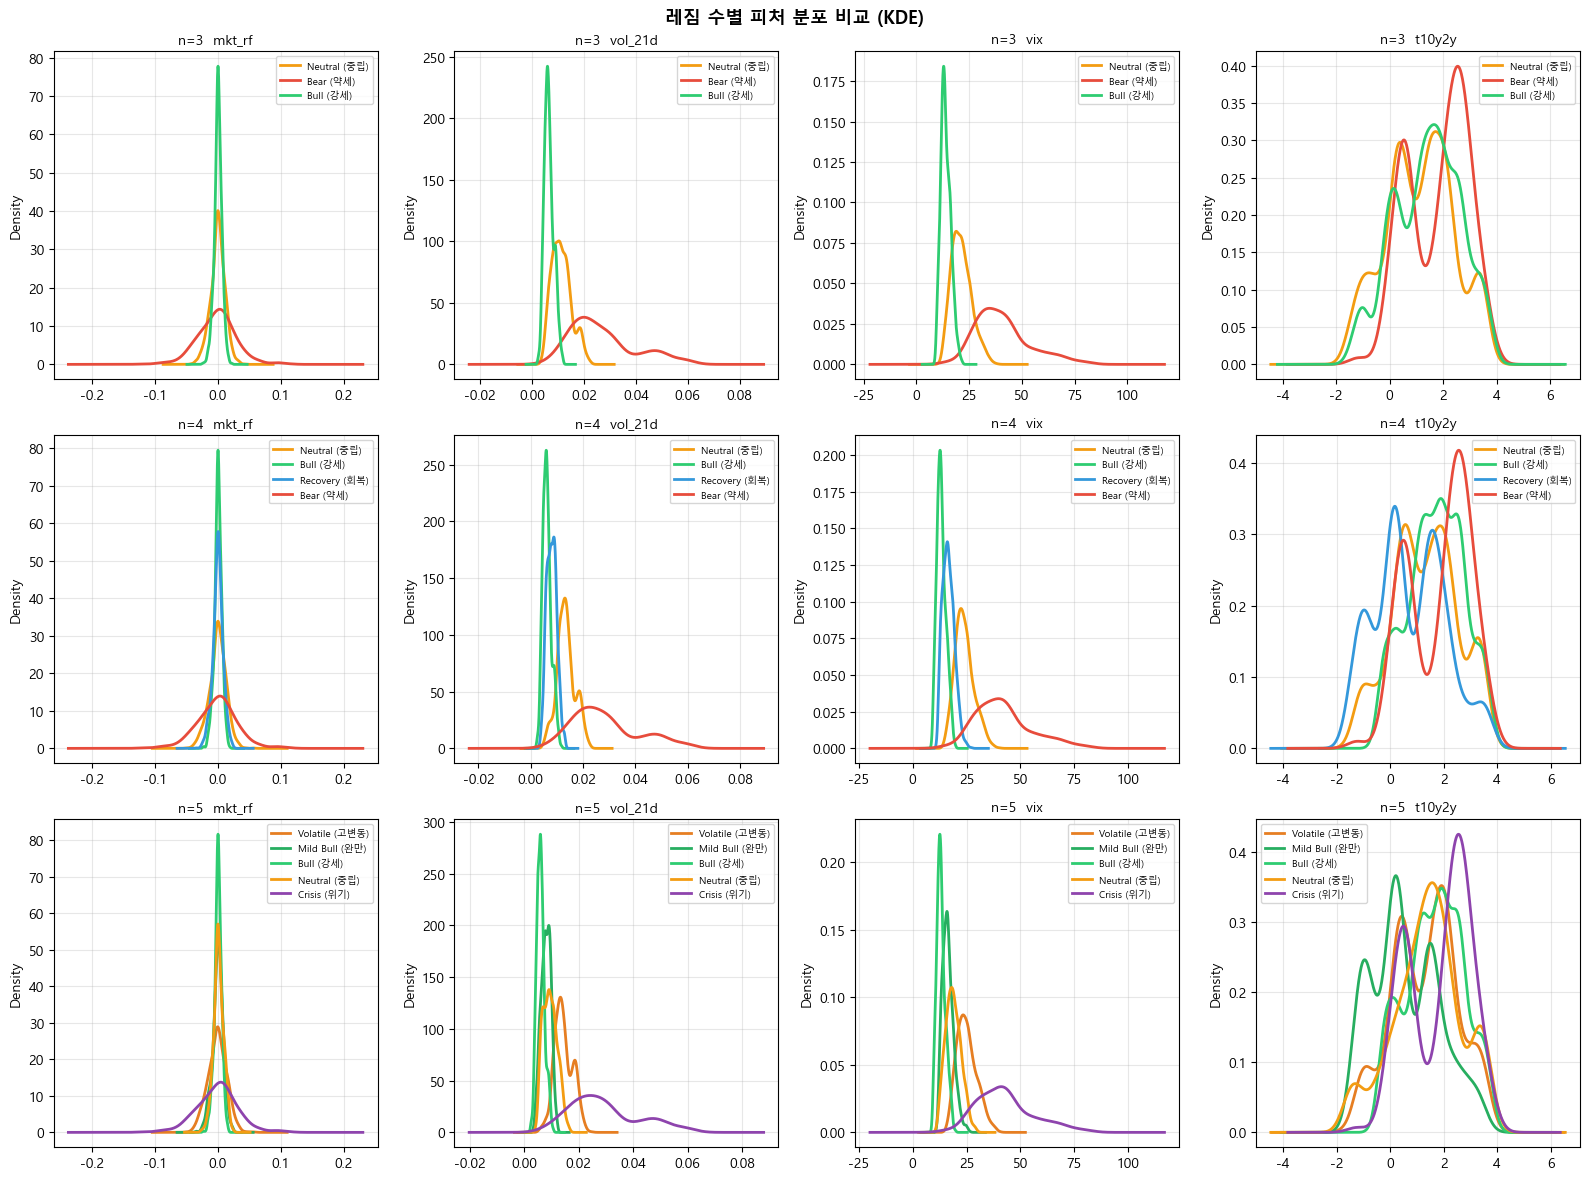

In [48]:
plot_feats = [f for f in ["mkt_rf", "vol_21d", "vix", "t10y2y"] if f in feat_df.columns]

fig, axes = plt.subplots(3, len(plot_feats), figsize=(4*len(plot_feats), 12))

for row_idx, n in enumerate([3, 4, 5]):
    r      = results[n]
    st_arr = r["states"]
    s2l    = r["state_to_label"]
    uq     = sorted(s2l.keys())
    for col_idx, fname in enumerate(plot_feats):
        ax = axes[row_idx][col_idx]
        for s in uq:
            lbl  = s2l[s]
            vals = feat_df.loc[st_arr == s, fname].dropna()
            if len(vals) < 2:
                continue
            vals.plot.kde(ax=ax, label=lbl, color=get_color(lbl, uq.index(s)), lw=2)
        ax.set_title(f"n={n}  {fname}", fontsize=10)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("레짐 수별 피처 분포 비교 (KDE)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "05_kde_comparison.png", bbox_inches="tight")
plt.show()

## 10. 섹터 ETF 수익률 비교 (n=3, 4, 5)

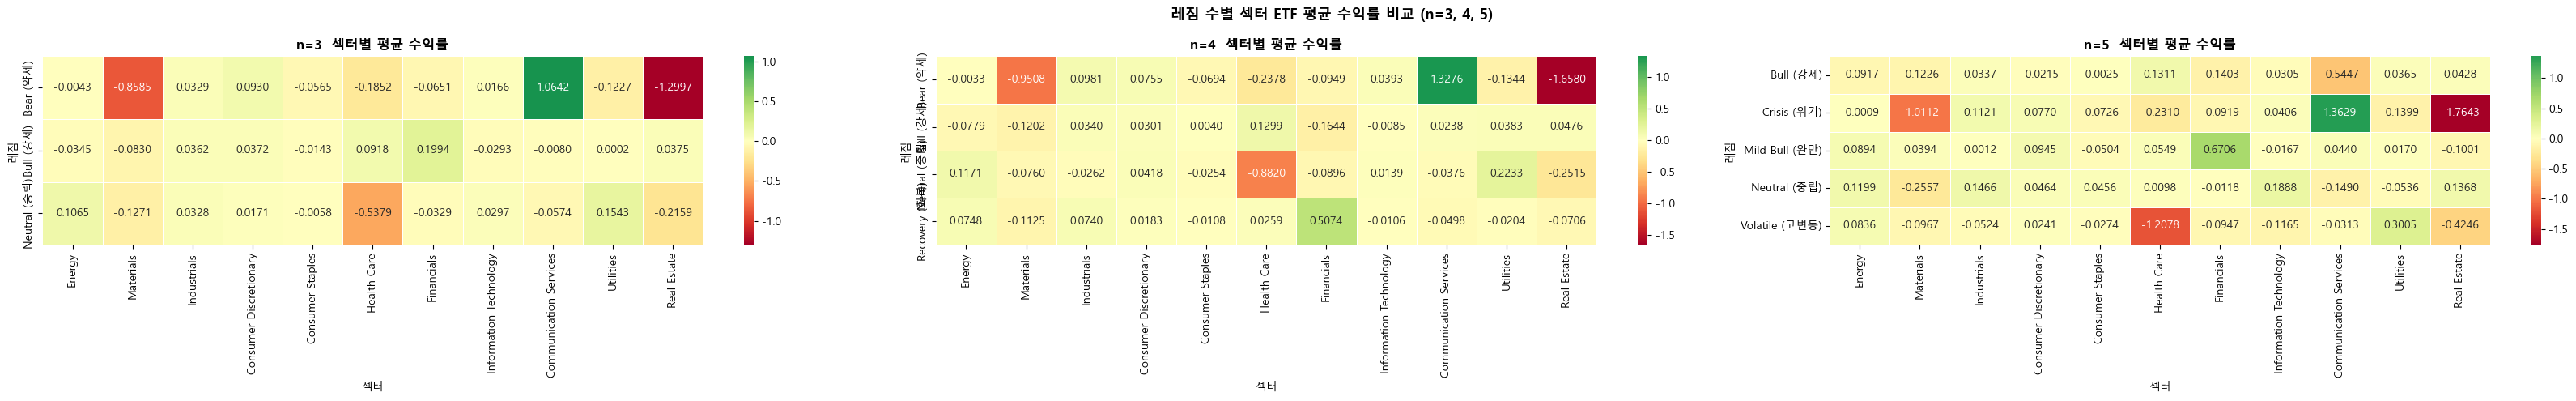

In [49]:
sector_cols = [c for c in df_raw.columns if c.endswith("_ret") and c != "mkt_ret_ew"]

if sector_cols:
    fig, axes = plt.subplots(1, 3, figsize=(max(18, len(sector_cols)*3), 5))
    for ax, n in zip(axes, [3, 4, 5]):
        r   = results[n]
        tmp = feat_df[[]].copy()
        tmp["regime"] = [r["state_to_label"][s] for s in r["states"]]
        merged = tmp.join(df_raw[sector_cols], how="left")
        sm = merged.groupby("regime")[sector_cols].mean()
        sm.columns = [c.replace("_ret", "") for c in sm.columns]
        sns.heatmap(sm, annot=True, fmt=".4f", cmap="RdYlGn",
                    center=0, linewidths=0.5, ax=ax)
        ax.set_title(f"n={n}  섹터별 평균 수익률", fontweight="bold")
        ax.set_xlabel("섹터"); ax.set_ylabel("레짐")
    plt.suptitle("레짐 수별 섹터 ETF 평균 수익률 비교 (n=3, 4, 5)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "06_sector_comparison.png", bbox_inches="tight")
    plt.show()
else:
    print("섹터 ETF 데이터 없음")

## 11. 최종 요약

In [50]:
print("=" * 60)
print("   HMM 레짐 비교 분석 요약")
print("=" * 60)
print(f"분석 기간: {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}")
print(f"총 거래일: {len(feat_df):,}일")

print(f"{'n':>3}  {'BIC':>22}  {'logL':>14}  수렴")
print("-" * 52)
for n in [3, 4, 5]:
    r    = results[n]
    star = "  ◀ 최적" if n == best_n else ""
    print(f"  {n}  {r['bic']:>22.1f}  {r['logL']:>14.4f}  {r['model'].monitor_.converged}{star}")

print(f"→ BIC 기준 최적 레짐 수: n={best_n}")

r_best = results[best_n]
print(f"─── 최근 10일 레짐 (n={best_n}) ─────────────────────────")
for dt, s in zip(feat_df.index[-10:], r_best["states"][-10:]):
    print(f"  {dt.date()}  →  {r_best['state_to_label'][s]}")

   HMM 레짐 비교 분석 요약
분석 기간: 2004-04-01 ~ 2026-02-27
총 거래일: 5,512일
  n                     BIC            logL  수렴
----------------------------------------------------
  3             810191784.3     -73493.0866  True
  4             775022631.2     -70302.7272  True
  5             753570578.4     -68356.6604  True  ◀ 최적
→ BIC 기준 최적 레짐 수: n=5
─── 최근 10일 레짐 (n=5) ─────────────────────────
  2026-02-13  →  Mild Bull (완만)
  2026-02-17  →  Mild Bull (완만)
  2026-02-18  →  Mild Bull (완만)
  2026-02-19  →  Mild Bull (완만)
  2026-02-20  →  Mild Bull (완만)
  2026-02-23  →  Mild Bull (완만)
  2026-02-24  →  Mild Bull (완만)
  2026-02-25  →  Mild Bull (완만)
  2026-02-26  →  Mild Bull (완만)
  2026-02-27  →  Mild Bull (완만)


=== Posterior 불확실성 (n=5, 전체 피처 모델) ===

  평균 max posterior : 0.985
  중앙값             : 1.000
  P(레짐) ≥ 0.9인 비율 : 95.1%
  P(레짐) ≥ 0.8인 비율 : 97.1%
  P(레짐) ≥ 0.7인 비율 : 98.4%
  P(레짐) ≥ 0.5인 비율 : 100.0%


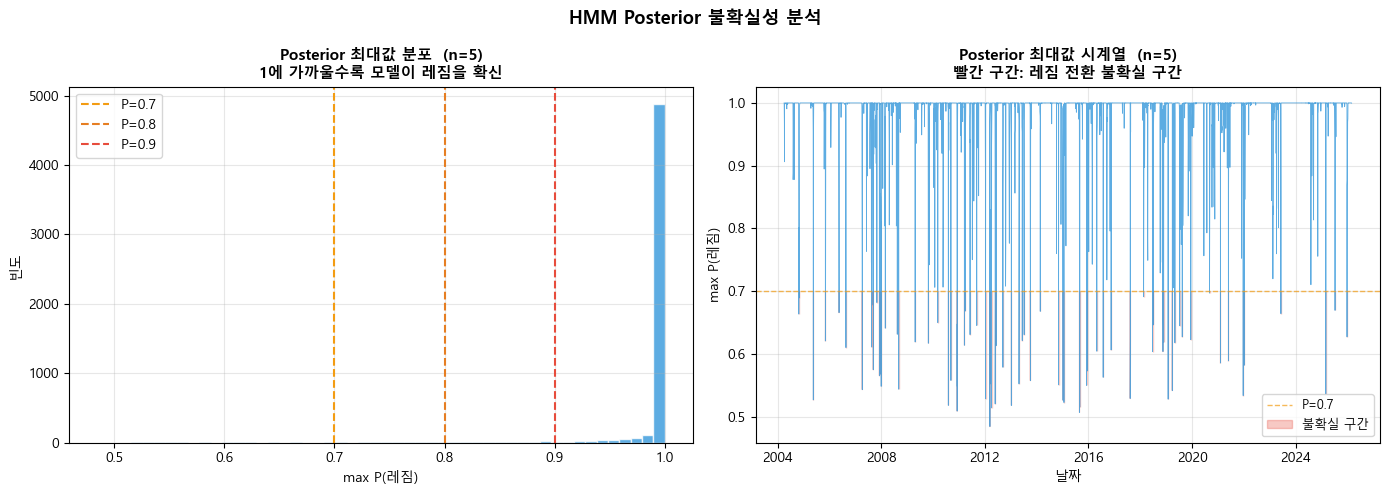


레짐 불확실 구간 (max posterior < 0.6): 0.7%


In [51]:
# ════════════════════════════════════════════════════════════════════════════
# 12. Posterior 불확실성 분석
#     모델이 레짐을 얼마나 확신하는가?
# ════════════════════════════════════════════════════════════════════════════
from scipy import stats as sp_stats

r_full = results[best_n]
posterior_full = r_full["posterior"]           # (T, n) 배열
max_post = posterior_full.max(axis=1)          # 각 시점의 최대 사후확률

print(f"=== Posterior 불확실성 (n={best_n}, 전체 피처 모델) ===\n")
print(f"  평균 max posterior : {max_post.mean():.3f}")
print(f"  중앙값             : {np.median(max_post):.3f}")
thresholds = [0.9, 0.8, 0.7, 0.5]
for th in thresholds:
    pct = (max_post >= th).mean() * 100
    print(f"  P(레짐) ≥ {th:.1f}인 비율 : {pct:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 히스토그램 ───────────────────────────────────────────────────────────────
axes[0].hist(max_post, bins=50, color="#3498db", edgecolor="white", alpha=0.8)
for th, color in zip([0.7, 0.8, 0.9], ["#f39c12","#e67e22","#e74c3c"]):
    axes[0].axvline(th, color=color, lw=1.5, linestyle="--", label=f"P={th}")
axes[0].set_title(f"Posterior 최대값 분포  (n={best_n})\n"
                  "1에 가까울수록 모델이 레짐을 확신",
                  fontweight="bold", fontsize=11)
axes[0].set_xlabel("max P(레짐)")
axes[0].set_ylabel("빈도")
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── 시계열 ───────────────────────────────────────────────────────────────────
axes[1].plot(feat_df.index, max_post, color="#3498db", lw=0.6, alpha=0.8)
axes[1].axhline(0.7, color="#f39c12", lw=1.0, linestyle="--", alpha=0.7, label="P=0.7")
axes[1].fill_between(feat_df.index, max_post, 0.7,
                     where=(max_post < 0.7), alpha=0.3, color="#e74c3c",
                     label="불확실 구간")
axes[1].set_title(f"Posterior 최대값 시계열  (n={best_n})\n"
                  "빨간 구간: 레짐 전환 불확실 구간",
                  fontweight="bold", fontsize=11)
axes[1].set_xlabel("날짜"); axes[1].set_ylabel("max P(레짐)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle("HMM Posterior 불확실성 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "P1_posterior_uncertainty.png", bbox_inches="tight")
plt.show()

# ── 불확실 구간이 언제인가 ────────────────────────────────────────────────────
uncertain_mask = max_post < 0.6
uncertain_pct  = uncertain_mask.mean() * 100
print(f"\n레짐 불확실 구간 (max posterior < 0.6): {uncertain_pct:.1f}%")

=== 레짐별 다음 날 수익률 (n=5) ===

레짐                       평균      중앙값      std     hit율     일수
--------------------------------------------------------------
  Neutral (중립)       +0.089%   +0.100%    0.876%     55.2%    992일
  Crisis (위기)        +0.056%   +0.230%    3.155%     53.6%    321일
  Mild Bull (완만)     +0.046%   +0.100%    0.866%     55.5%   1209일
  Bull (강세)          +0.032%   +0.060%    0.614%     55.2%   1894일
  Volatile (고변동)     +0.005%   +0.030%    1.487%     50.7%   1095일

Kruskal-Wallis H=5.01,  p=0.2863  (유의하지 않음 ❌)


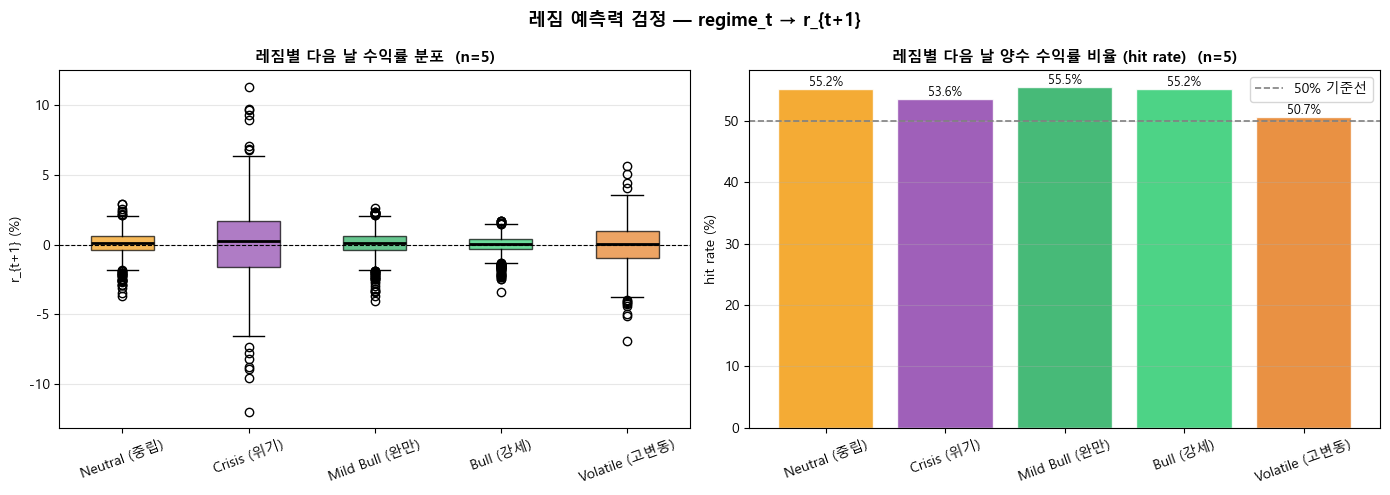

In [52]:
# ════════════════════════════════════════════════════════════════════════════
# 13. 레짐 예측력 검정 — regime_t → r_{t+1}
#     레짐이 다음 날 수익률을 통계적으로 구분하는가?
# ════════════════════════════════════════════════════════════════════════════
next_ret = feat_df["mkt_rf"].shift(-1)   # t+1 수익률

regime_arr = np.array([results[best_n]["state_to_label"][s]
                        for s in results[best_n]["states"]])

regime_ret = {}
for lbl in set(regime_arr):
    mask = (regime_arr == lbl) & next_ret.notna().values
    regime_ret[lbl] = next_ret.values[mask]

print(f"=== 레짐별 다음 날 수익률 (n={best_n}) ===\n")
print(f"{'레짐':<18} {'평균':>8} {'중앙값':>8} {'std':>8} {'hit율':>8} {'일수':>6}")
print("-" * 62)

all_groups   = list(regime_ret.values())
label_order  = sorted(regime_ret.keys(),
                      key=lambda l: np.mean(regime_ret[l]), reverse=True)

for lbl in label_order:
    vals   = regime_ret[lbl]
    hit    = (vals > 0).mean() * 100
    print(f"  {lbl:<16}  {np.mean(vals)*100:>+7.3f}%  "
          f"{np.median(vals)*100:>+7.3f}%  "
          f"{np.std(vals)*100:>7.3f}%  "
          f"{hit:>7.1f}%  {len(vals):>5}일")

# ── Kruskal-Wallis 검정 ───────────────────────────────────────────────────────
h_stat, p_val = sp_stats.kruskal(*all_groups)
print(f"\nKruskal-Wallis H={h_stat:.2f},  p={p_val:.4f}  "
      f"({'레짐 간 수익률 분포 유의미하게 다름 ✅' if p_val < 0.05 else '유의하지 않음 ❌'})")

# ── 레짐별 수익률 분포 시각화 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 박스플롯
box_data   = [regime_ret[l] * 100 for l in label_order]
bp = axes[0].boxplot(box_data, labels=label_order, patch_artist=True,
                     medianprops=dict(color="black", lw=2))
colors_box = [get_color(l, i) for i, l in enumerate(label_order)]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].set_title(f"레짐별 다음 날 수익률 분포  (n={best_n})", fontweight="bold", fontsize=11)
axes[0].set_ylabel("r_{t+1} (%)"); axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

# Hit rate (양수 수익률 비율)
hit_rates = [(regime_ret[l] > 0).mean() * 100 for l in label_order]
bar_colors = [get_color(l, i) for i, l in enumerate(label_order)]
axes[1].bar(label_order, hit_rates, color=bar_colors, edgecolor="white", alpha=0.85)
axes[1].axhline(50, color="gray", lw=1.2, linestyle="--", label="50% 기준선")
axes[1].set_title(f"레짐별 다음 날 양수 수익률 비율 (hit rate)  (n={best_n})",
                  fontweight="bold", fontsize=11)
axes[1].set_ylabel("hit rate (%)"); axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for i, (lbl, rate) in enumerate(zip(label_order, hit_rates)):
    axes[1].text(i, rate + 0.5, f"{rate:.1f}%", ha="center", fontsize=9)

plt.suptitle("레짐 예측력 검정 — regime_t → r_{t+1}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "P2_regime_predictive_power.png", bbox_inches="tight")
plt.show()

## 14. CSV 저장

In [25]:
# n=3,4,5 각각 CSV 저장
for n in [3, 4, 5]:
    r   = results[n]
    out = feat_df[["mkt_rf", "vol_21d", "vix"]].copy()
    out["state"]  = r["states"]
    out["regime"] = [r["state_to_label"][s] for s in r["states"]]
    for i in range(n):
        out[f"prob_{r['state_to_label'][i]}"] = r["posterior"][:, i]
    out.to_csv(OUT_DIR / f"hmm_n{n}_results.csv")
    r["stats"].to_csv(OUT_DIR / f"hmm_n{n}_summary.csv", index=False)

print("✅ CSV 저장 완료")
for n in [3, 4, 5]:
    print(f"   - hmm_n{n}_results.csv  /  hmm_n{n}_summary.csv")

✅ CSV 저장 완료
   - hmm_n3_results.csv  /  hmm_n3_summary.csv
   - hmm_n4_results.csv  /  hmm_n4_summary.csv
   - hmm_n5_results.csv  /  hmm_n5_summary.csv


---

## 피처 정제 후 재분석 (6개 선별 피처)

검증 결과를 바탕으로 **순환 논리 없이** 피처를 먼저 선별한 뒤 HMM을 재학습합니다.

| 선택 근거 | 포함 피처 |
|-----------|-----------|
| Ablation ΔBIC > 0 + KW 유의 | `vix`, `vol_21d`, `vol_63d`, `mkt_rf` |
| HMM 분리력 상위 + 경제적 의미 | `vix_chg`, `t10y2y` |
| **제거** | `mkt_ret_ew` (mkt_rf 중복), `ret_5d/21d`, `smb`, `hml`, `mom`, `wti_ret`, `gold_ret`, `dxy_ret`, `t10y2y_chg` (Ablation 음수) |

정제 피처 (6개): ['mkt_rf', 'vol_21d', 'vol_63d', 'vix', 'vix_chg', 't10y2y']

  n        k(파라미터수)            logL                     BIC  수렴
-----------------------------------------------------------------
  3              89       -21952.94             242009950.7  True
  4             123       -19730.49             217509971.2  True
  5             159       -18187.83             200504035.9  True

→ BIC 최적 n = 5


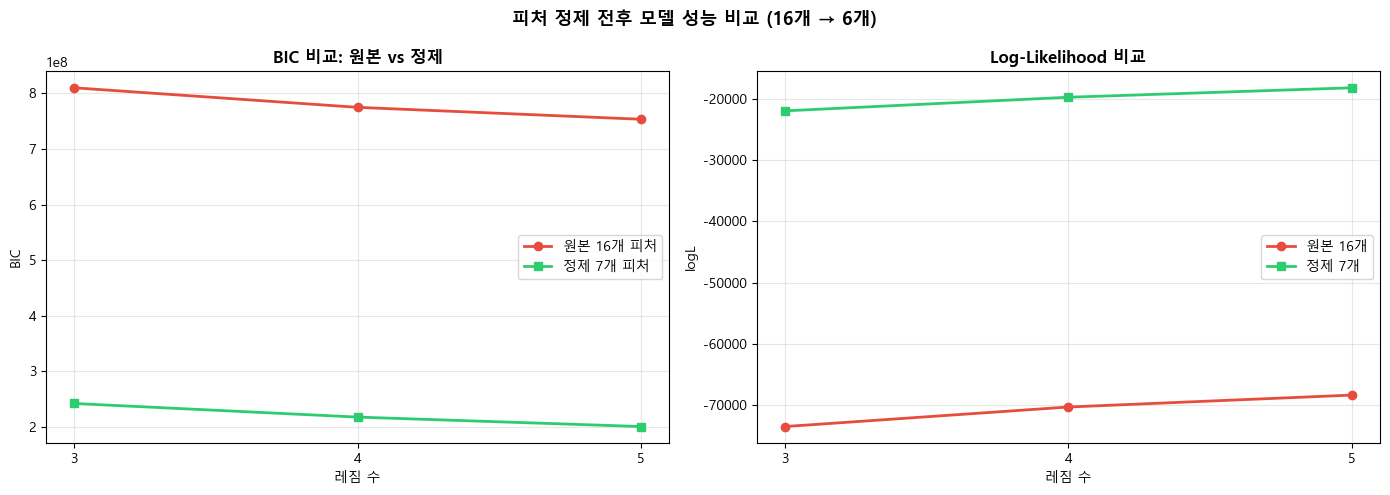


  n                  원본 BIC                  정제 BIC            ΔBIC  판정
------------------------------------------------------------------------------
  3             810191784.3             242009950.7    -568181833.6  ↓ 개선
  4             775022631.2             217509971.2    -557512660.0  ↓ 개선
  5             753570578.4             200504035.9    -553066542.5  ↓ 개선


In [53]:
# ── 피처 선택 & 스케일링 & n=3,4,5 학습 ─────────────────────────────────────
REFINED_FEATS = ["mkt_rf", "vol_21d", "vol_63d", "vix", "vix_chg", "t10y2y"]
feat_r   = feat_df[REFINED_FEATS]
scaler_r = StandardScaler()
X_r      = scaler_r.fit_transform(feat_r.values)

print(f"정제 피처 ({len(REFINED_FEATS)}개): {REFINED_FEATS}\n")
print(f"{'n':>3}  {'k(파라미터수)':>14}  {'logL':>14}  {'BIC':>22}  수렴")
print("-" * 65)
results_r = {}
for n in [3, 4, 5]:
    r = fit_hmm(n, X_r, feat_r, seed=SEED)
    results_r[n] = r
    print(f"  {n}  {r['k']:>14d}  {r['logL']:>14.2f}  {r['bic']:>22.1f}  {r['model'].monitor_.converged}")

best_n_r = min(results_r, key=lambda n: results_r[n]["bic"])
print(f"\n→ BIC 최적 n = {best_n_r}")

# ── 원본 vs 정제 BIC 비교 ─────────────────────────────────────────────────────
ns = [3, 4, 5]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ns, [results[n]["bic"]   for n in ns], marker="o", color="#e74c3c", lw=2, label="원본 16개 피처")
axes[0].plot(ns, [results_r[n]["bic"] for n in ns], marker="s", color="#2ecc71", lw=2, label="정제 7개 피처")
axes[0].set_title("BIC 비교: 원본 vs 정제", fontweight="bold", fontsize=12)
axes[0].set_xlabel("레짐 수"); axes[0].set_ylabel("BIC")
axes[0].set_xticks(ns); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ns, [results[n]["logL"]   for n in ns], marker="o", color="#e74c3c", lw=2, label="원본 16개")
axes[1].plot(ns, [results_r[n]["logL"] for n in ns], marker="s", color="#2ecc71", lw=2, label="정제 7개")
axes[1].set_title("Log-Likelihood 비교", fontweight="bold", fontsize=12)
axes[1].set_xlabel("레짐 수"); axes[1].set_ylabel("logL")
axes[1].set_xticks(ns); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("피처 정제 전후 모델 성능 비교 (16개 → 6개)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R1_bic_comparison_refined.png", bbox_inches="tight")
plt.show()

print(f"\n{'n':>3}  {'원본 BIC':>22}  {'정제 BIC':>22}  {'ΔBIC':>14}  판정")
print("-" * 78)
for n in ns:
    delta = results_r[n]["bic"] - results[n]["bic"]
    print(f"  {n}  {results[n]['bic']:>22.1f}  {results_r[n]['bic']:>22.1f}  "
          f"{delta:>+14.1f}  {'↓ 개선' if delta < 0 else '↑ 악화'}")

   정제 피처 기반 레짐 통계 (6개 피처)

── n=3  (BIC=242009951,  logL=-21952.94,  수렴=True)
  [Bull (강세)       ]   44.5%  (2454일)  수익=+0.086%  변동=0.643%  VIX=13.5
  [Neutral (중립)    ]   42.5%  (2341일)  수익=+0.015%  변동=1.018%  VIX=20.0
  [Bear (약세)       ]   13.0%  ( 717일)  수익=-0.024%  변동=2.215%  VIX=34.6

── n=4  (BIC=217509971,  logL=-19730.49,  수렴=True)
  [Bull (강세)       ]   27.5%  (1518일)  수익=+0.085%  변동=0.665%  VIX=14.0
  [Recovery (회복)   ]   25.3%  (1393일)  수익=+0.069%  변동=0.677%  VIX=14.0
  [Neutral (중립)    ]   36.9%  (2034일)  수익=+0.025%  변동=1.106%  VIX=21.1
  [Bear (약세)       ]   10.3%  ( 567일)  수익=-0.085%  변동=2.376%  VIX=37.0

── n=5  (BIC=200504036,  logL=-18187.83,  수렴=True) ◀ BIC 최적
  [Bull (강세)       ]   19.8%  (1092일)  수익=+0.098%  변동=0.666%  VIX=13.4
  [Mild Bull (완만)  ]   24.7%  (1362일)  수익=+0.088%  변동=0.661%  VIX=13.8
  [Neutral (중립)    ]   21.7%  (1197일)  수익=+0.032%  변동=0.770%  VIX=17.6
  [Volatile (고변동)  ]   24.6%  (1356일)  수익=-0.005%  변동=1.308%  VIX=23.0
  [Crisis (위기)     ]    9.2%

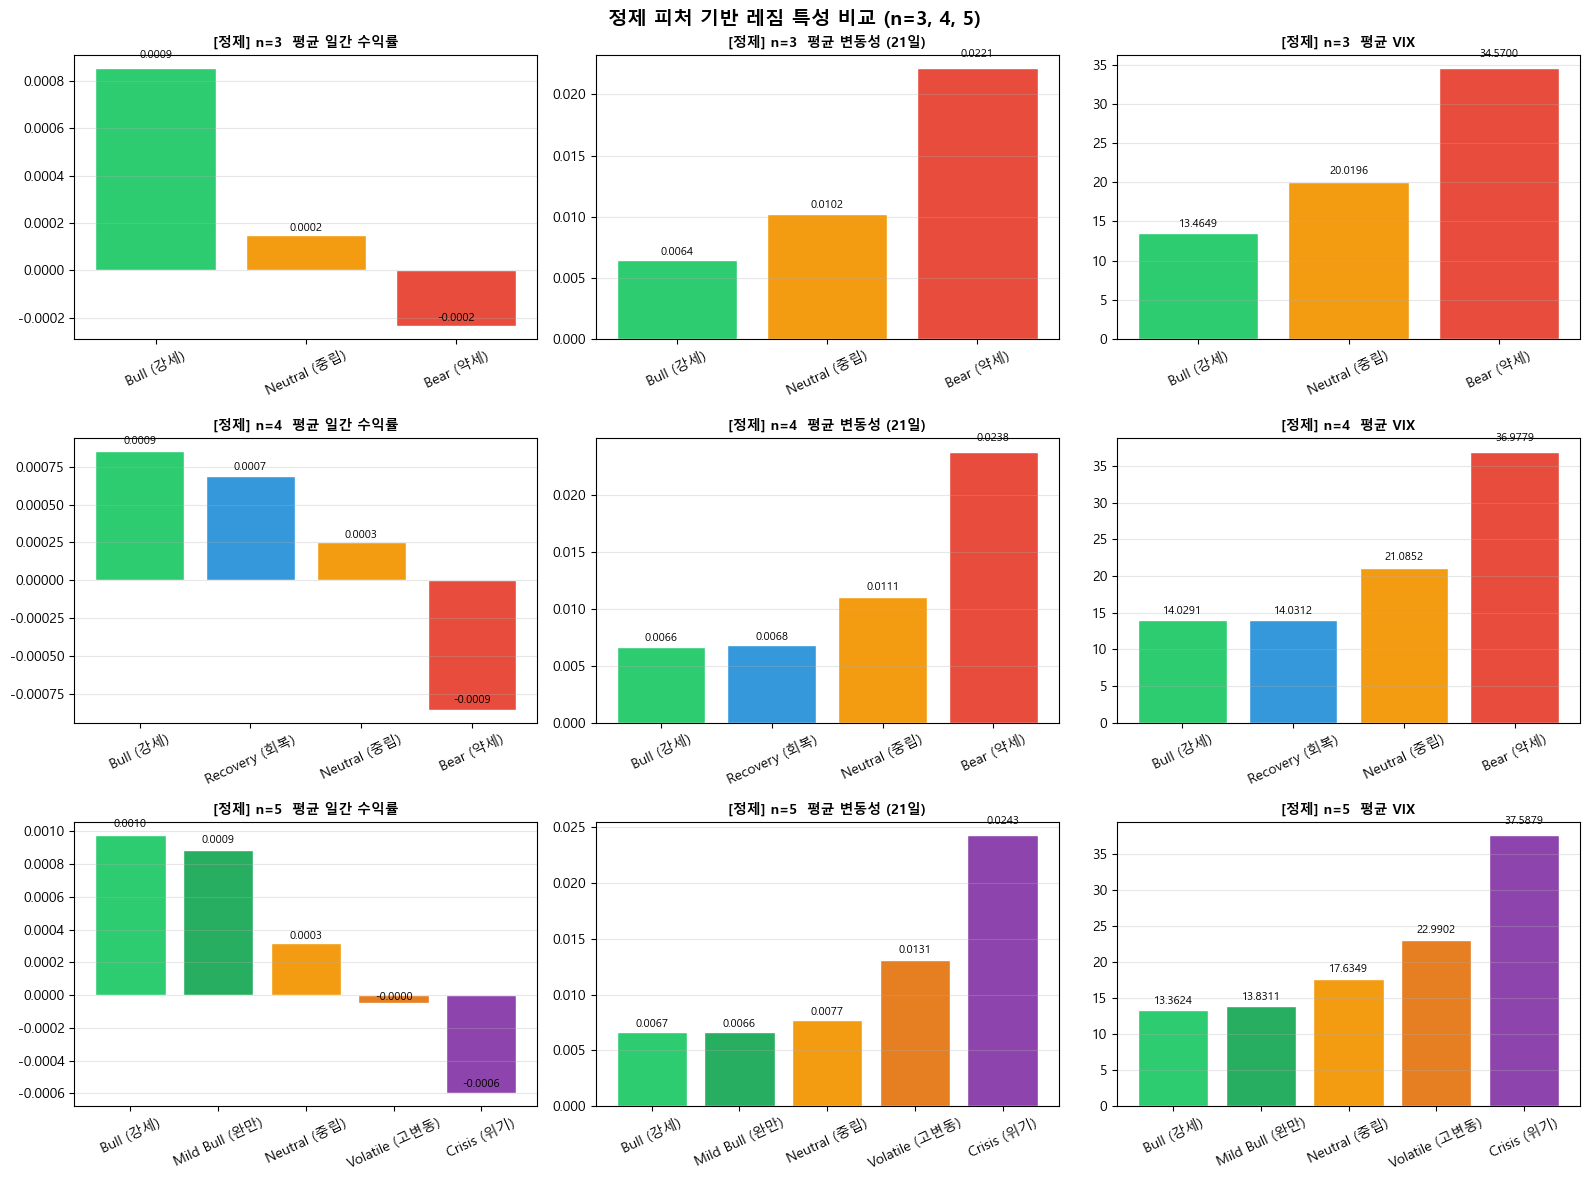

In [54]:
# ── 정제 피처 레짐 통계 ───────────────────────────────────────────────────────
print("=" * 72)
print("   정제 피처 기반 레짐 통계 (6개 피처)")
print("=" * 72)
for n in [3, 4, 5]:
    r    = results_r[n]
    mark = " ◀ BIC 최적" if n == best_n_r else ""
    print(f"\n── n={n}  (BIC={r['bic']:.0f},  logL={r['logL']:.2f},  수렴={r['model'].monitor_.converged}){mark}")
    for _, row in r["stats"].iterrows():
        print(f"  [{row['label']:<16}]  {row['pct']:5.1f}%  ({int(row['count']):4d}일)  "
              f"수익={row['mean_ret']*100:+.3f}%  "
              f"변동={row['mean_vol']*100:.3f}%  "
              f"VIX={row['mean_vix']:.1f}")

# ── 레짐 통계 바 차트 ─────────────────────────────────────────────────────────
metrics = [("mean_ret", "평균 일간 수익률"), ("mean_vol", "평균 변동성 (21일)"), ("mean_vix", "평균 VIX")]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for row_idx, n in enumerate([3, 4, 5]):
    r  = results_r[n]
    st = r["stats"]
    for col_idx, (col, title) in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        colors = [get_color(row["label"], i) for i, row in st.iterrows()]
        bars   = ax.bar(st["label"], st[col], color=colors, edgecolor="white")
        ax.set_title(f"[정제] n={n}  {title}", fontweight="bold", fontsize=10)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.3)
        for bar, val in zip(bars, st[col]):
            if pd.notna(val):
                ypos = bar.get_height() + abs(bar.get_height()) * 0.03
                ax.text(bar.get_x() + bar.get_width()/2, ypos,
                        f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("정제 피처 기반 레짐 특성 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R2_regime_stats_refined.png", bbox_inches="tight")
plt.show()

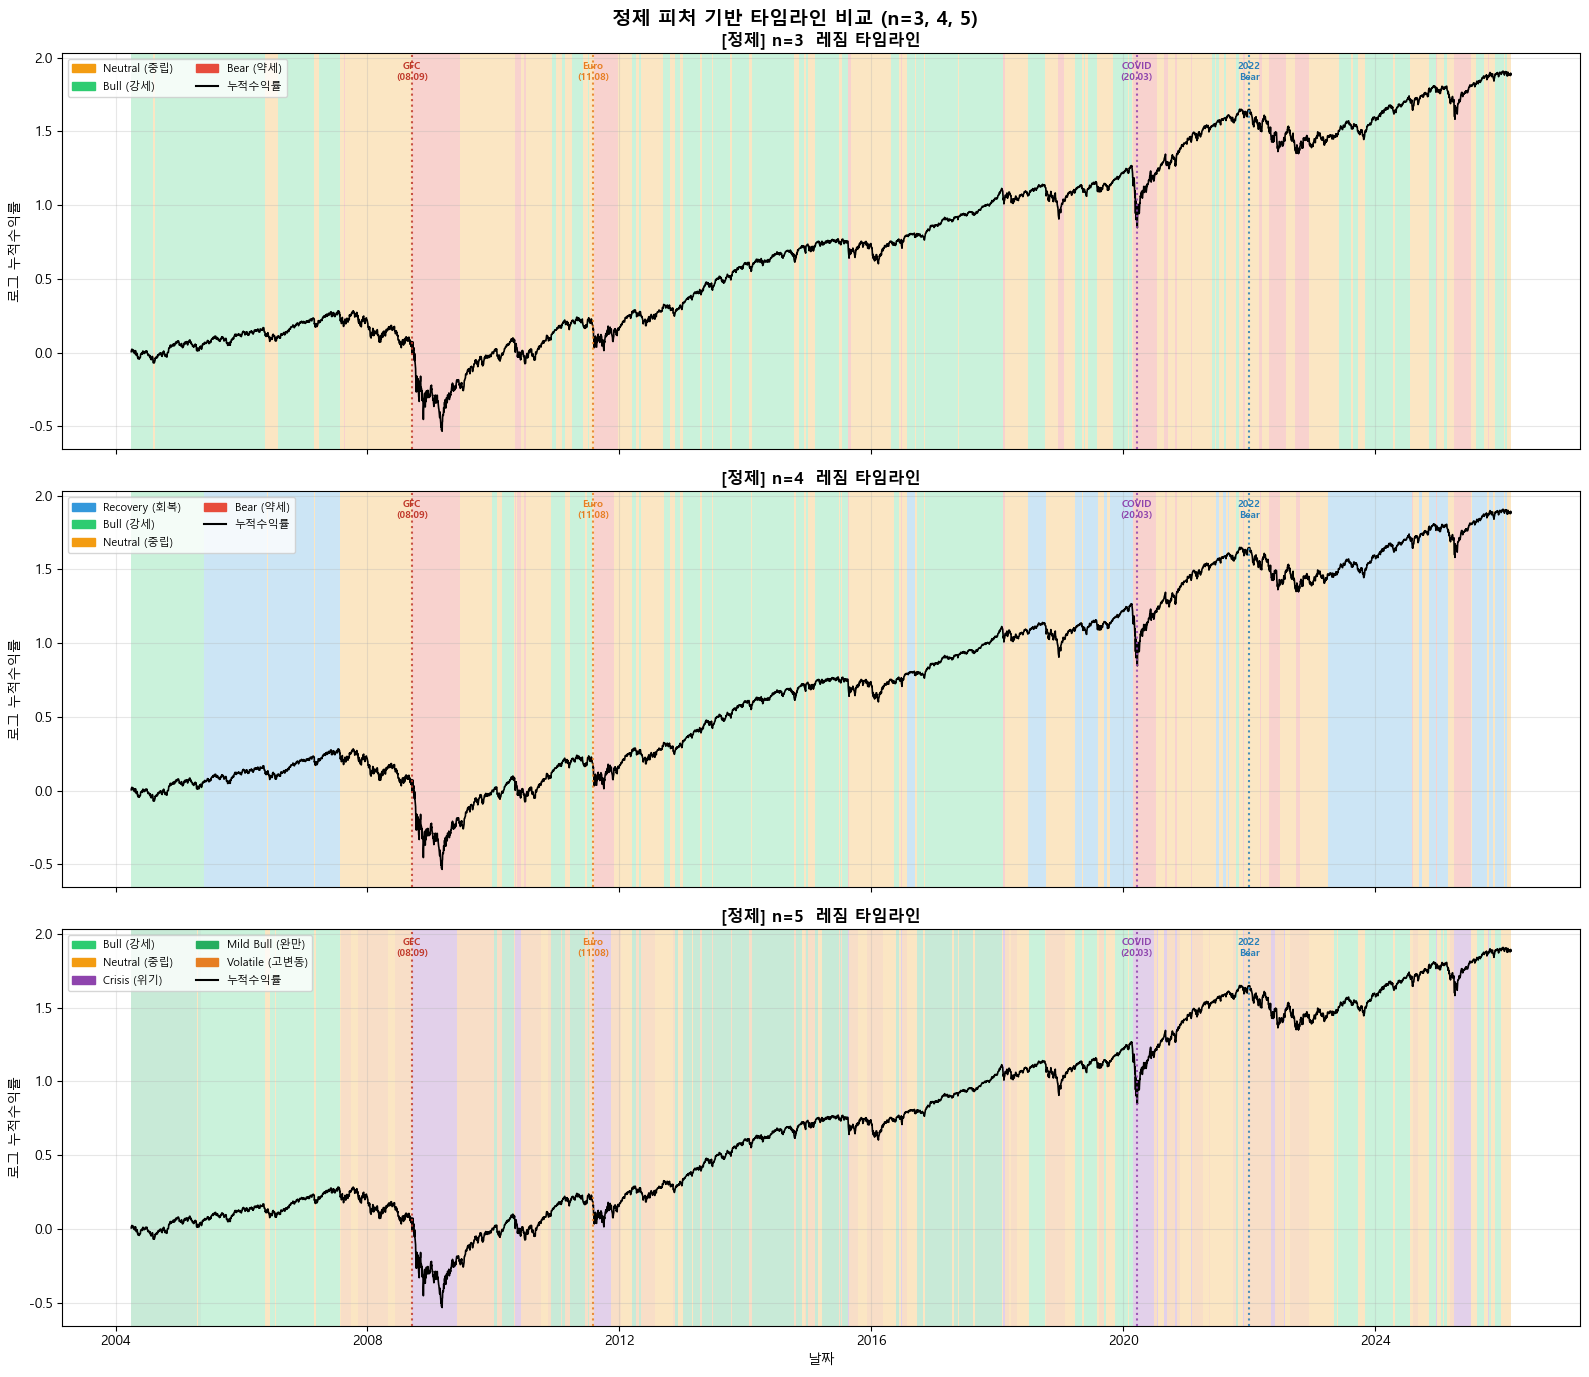

In [57]:
# ── 정제 피처 기반 타임라인 ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

for ax, n in zip(axes, [3, 4, 5]):
    r   = results_r[n]
    st  = r["states"]
    s2l = r["state_to_label"]
    uq  = sorted(s2l.keys())

    ax.plot(dates, mkt_cum.values, color="black", lw=1.2)

    prev_s = st[0]; t0 = dates[0]
    for i in range(1, len(st)):
        if st[i] != prev_s or i == len(st) - 1:
            lbl = s2l[prev_s]
            ax.axvspan(t0, dates[i], alpha=0.25, color=get_color(lbl, uq.index(prev_s)), lw=0)
            prev_s = st[i]; t0 = dates[i]

    # ── 주요 사건 마커 ──────────────────────────────────────────────────────
    y_min, y_max = ax.get_ylim()
    for label, (date_str, ecolor) in EVENTS.items():
        dt = pd.Timestamp(date_str)
        if dates[0] <= dt <= dates[-1]:
            ax.axvline(dt, color=ecolor, lw=1.5, linestyle=":", alpha=0.85, zorder=5)
            ax.text(dt, y_max * 0.97, label, fontsize=7, color=ecolor,
                    ha="center", va="top", fontweight="bold")

    patches = [mpatches.Patch(color=get_color(s2l[s], uq.index(s)), label=s2l[s]) for s in uq]
    ax.legend(handles=patches + [plt.Line2D([0],[0], color="black", lw=1.5, label="누적수익률")],
              loc="upper left", fontsize=8, ncol=2)
    ax.set_ylabel("로그 누적수익률")
    ax.set_title(f"[정제] n={n}  레짐 타임라인", fontweight="bold", fontsize=12)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("날짜")
plt.suptitle("정제 피처 기반 타임라인 비교 (n=3, 4, 5)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R3_timeline_refined.png", bbox_inches="tight")
plt.show()

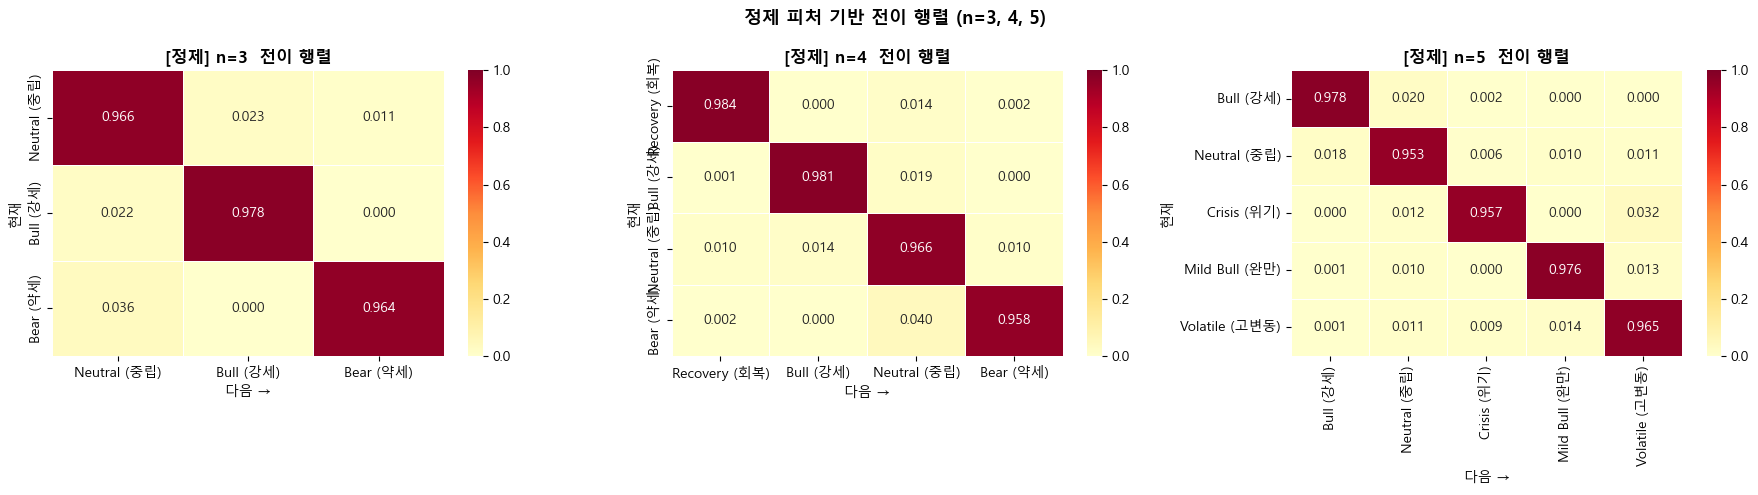

─── 최근 10일 레짐 (정제 모델, n=5) ─────────────────────────
  2026-02-13  →  Neutral (중립)
  2026-02-17  →  Neutral (중립)
  2026-02-18  →  Neutral (중립)
  2026-02-19  →  Neutral (중립)
  2026-02-20  →  Neutral (중립)
  2026-02-23  →  Neutral (중립)
  2026-02-24  →  Neutral (중립)
  2026-02-25  →  Neutral (중립)
  2026-02-26  →  Neutral (중립)
  2026-02-27  →  Neutral (중립)

✅ 정제 피처 결과 CSV 저장 완료
   - hmm_refined_n3_results.csv  /  hmm_refined_n3_summary.csv
   - hmm_refined_n4_results.csv  /  hmm_refined_n4_summary.csv
   - hmm_refined_n5_results.csv  /  hmm_refined_n5_summary.csv


In [29]:
# ── 정제 피처 기반 전이 행렬 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, n in zip(axes, [3, 4, 5]):
    r        = results_r[n]
    labels   = [r["state_to_label"][i] for i in range(n)]
    trans_df = pd.DataFrame(r["model"].transmat_, index=labels, columns=labels)
    sns.heatmap(trans_df, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(f"[정제] n={n}  전이 행렬", fontweight="bold", fontsize=12)
    ax.set_xlabel("다음 →"); ax.set_ylabel("현재")

plt.suptitle("정제 피처 기반 전이 행렬 (n=3, 4, 5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R4_transition_refined.png", bbox_inches="tight")
plt.show()

# ── 최근 레짐 & CSV 저장 ─────────────────────────────────────────────────────
print(f"─── 최근 10일 레짐 (정제 모델, n={best_n_r}) ─────────────────────────")
for dt, s in zip(dates[-10:], results_r[best_n_r]["states"][-10:]):
    print(f"  {dt.date()}  →  {results_r[best_n_r]['state_to_label'][s]}")

for n in [3, 4, 5]:
    r   = results_r[n]
    out = feat_r[["mkt_rf", "vol_21d", "vix"]].copy()
    out["state"]  = r["states"]
    out["regime"] = [r["state_to_label"][s] for s in r["states"]]
    for i in range(n):
        out[f"prob_{r['state_to_label'][i]}"] = r["posterior"][:, i]
    out.to_csv(OUT_DIR / f"hmm_refined_n{n}_results.csv")
    r["stats"].to_csv(OUT_DIR / f"hmm_refined_n{n}_summary.csv", index=False)

print("\n✅ 정제 피처 결과 CSV 저장 완료")
for n in [3, 4, 5]:
    print(f"   - hmm_refined_n{n}_results.csv  /  hmm_refined_n{n}_summary.csv")

=== [정제 모델 n=5] 레짐별 수익률 예측력 ===
── 다음 날 (t+1)  ----------------------------------------
  레짐                       평균      중앙값      std     hit율     일수
  ----------------------------------------------------------
  Crisis (위기)         +0.061%   +0.220%    2.733%     53.9%    505일
  Bull (강세)           +0.058%   +0.085%    0.658%     56.0%   1092일
  Mild Bull (완만)      +0.048%   +0.080%    0.638%     56.6%   1362일
  Neutral (중립)        +0.031%   +0.060%    0.883%     53.6%   1196일
  Volatile (고변동)      +0.022%   +0.040%    1.294%     51.3%   1356일
  Kruskal-Wallis  H=3.07,  p=0.5469  (유의하지 않음 ❌)
── 다음 달 (t+1:t+21 누적)  ----------------------------------------
  레짐                       평균      중앙값      std     hit율     일수
  ----------------------------------------------------------
  Crisis (위기)         +1.867%   +3.170%    8.305%     68.1%    505일
  Volatile (고변동)      +0.994%   +2.200%    5.436%     65.7%   1356일
  Neutral (중립)        +0.989%   +1.400%    3.319%     67.6%   1176일
  Mil

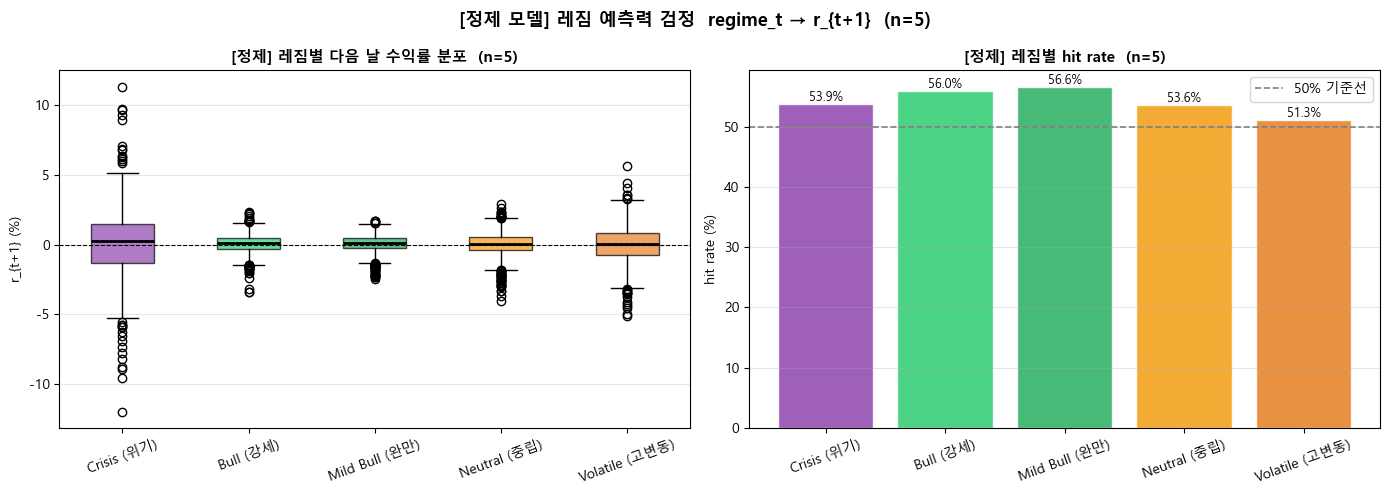

In [58]:
# ════════════════════════════════════════════════════════════════════════════
# [정제] 레짐 예측력 검정 — regime_t → r_{t+1} / r_{t+1:t+21}
#     정제 피처 모델 레짐이 다음 날 / 다음 달 수익률을 구분하는가?
#     BL 월간 리밸런싱 활용 가능성 확인
# ════════════════════════════════════════════════════════════════════════════
r_ref        = results_r[best_n_r]
regime_arr_r = np.array([r_ref["state_to_label"][s] for s in r_ref["states"]])

next_ret_1d  = feat_df["mkt_rf"].shift(-1)                        # t+1 일간 수익률
next_ret_21d = feat_df["mkt_rf"].rolling(21).sum().shift(-21)     # t+1:t+21 누적 수익률

print(f"=== [정제 모델 n={best_n_r}] 레짐별 수익률 예측력 ===")

for horizon, ret_ser in [("다음 날 (t+1)", next_ret_1d),
                          ("다음 달 (t+1:t+21 누적)", next_ret_21d)]:
    regime_ret_r = {}
    for lbl in set(regime_arr_r):
        mask = (regime_arr_r == lbl) & ret_ser.notna().values
        regime_ret_r[lbl] = ret_ser.values[mask]

    label_ord = sorted(regime_ret_r, key=lambda l: np.mean(regime_ret_r[l]), reverse=True)

    print(f"── {horizon} ", "-" * 40)
    print(f"  {'레짐':<18} {'평균':>8} {'중앙값':>8} {'std':>8} {'hit율':>8} {'일수':>6}")
    print("  " + "-" * 58)
    for lbl in label_ord:
        v   = regime_ret_r[lbl]
        hit = (v > 0).mean() * 100
        print(f"  {lbl:<18} {np.mean(v)*100:>+7.3f}%  "
              f"{np.median(v)*100:>+7.3f}%  "
              f"{np.std(v)*100:>7.3f}%  "
              f"{hit:>7.1f}%  {len(v):>5}일")

    h_stat_r, p_val_r = sp_stats.kruskal(*regime_ret_r.values())
    sig = "유의미하게 다름 ✅" if p_val_r < 0.05 else "유의하지 않음 ❌"
    print(f"  Kruskal-Wallis  H={h_stat_r:.2f},  p={p_val_r:.4f}  ({sig})")

# ── 시각화 (다음 날 기준) ─────────────────────────────────────────────────────
regime_ret_1d = {}
for lbl in set(regime_arr_r):
    mask = (regime_arr_r == lbl) & next_ret_1d.notna().values
    regime_ret_1d[lbl] = next_ret_1d.values[mask]

label_ord1 = sorted(regime_ret_1d, key=lambda l: np.mean(regime_ret_1d[l]), reverse=True)
colors_r   = [get_color(l, i) for i, l in enumerate(label_ord1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bp = axes[0].boxplot([regime_ret_1d[l] * 100 for l in label_ord1],
                     labels=label_ord1, patch_artist=True,
                     medianprops=dict(color="black", lw=2))
for patch, color in zip(bp["boxes"], colors_r):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].set_title(f"[정제] 레짐별 다음 날 수익률 분포  (n={best_n_r})",
                  fontweight="bold", fontsize=11)
axes[0].set_ylabel("r_{t+1} (%)"); axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

hit_rates_r = [(regime_ret_1d[l] > 0).mean() * 100 for l in label_ord1]
axes[1].bar(label_ord1, hit_rates_r, color=colors_r, edgecolor="white", alpha=0.85)
axes[1].axhline(50, color="gray", lw=1.2, linestyle="--", label="50% 기준선")
axes[1].set_title(f"[정제] 레짐별 hit rate  (n={best_n_r})",
                  fontweight="bold", fontsize=11)
axes[1].set_ylabel("hit rate (%)"); axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for i, (lbl, rate) in enumerate(zip(label_ord1, hit_rates_r)):
    axes[1].text(i, rate + 0.5, f"{rate:.1f}%", ha="center", fontsize=9)

plt.suptitle(f"[정제 모델] 레짐 예측력 검정  regime_t → r_{{t+1}}  (n={best_n_r})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R6_predictive_power_refined.png", bbox_inches="tight")
plt.show()

=== [정제 모델 n=5] Posterior 불확실성 ===
  평균 max posterior : 0.982
  중앙값             : 1.000
  P ≥ 0.9 비율      : 94.3%
  P ≥ 0.8 비율      : 96.4%
  P ≥ 0.7 비율      : 97.8%
  P ≥ 0.5 비율      : 100.0%
  불확실 구간 (P<0.6): 1.1%


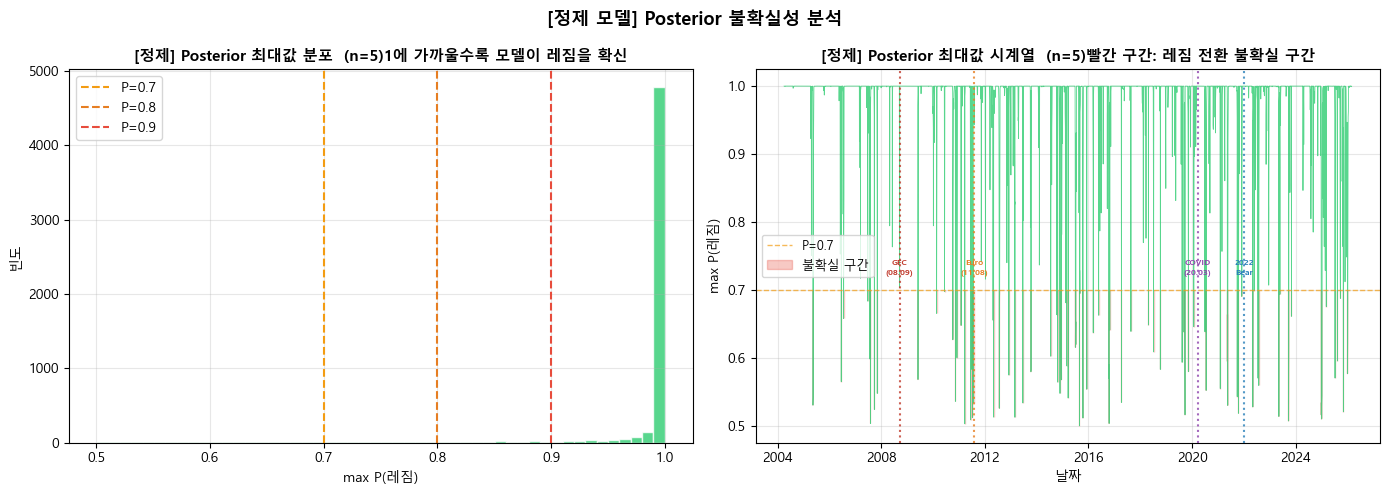

In [61]:
# ════════════════════════════════════════════════════════════════════════════
# [정제] Posterior 불확실성 분석
#     정제 피처 모델이 레짐을 얼마나 확신하는가?
# ════════════════════════════════════════════════════════════════════════════
r_ref_post   = results_r[best_n_r]
post_r       = r_ref_post["posterior"]        # (T, n) 배열
max_post_r   = post_r.max(axis=1)             # 각 시점 최대 사후확률

print(f"=== [정제 모델 n={best_n_r}] Posterior 불확실성 ===")
print(f"  평균 max posterior : {max_post_r.mean():.3f}")
print(f"  중앙값             : {np.median(max_post_r):.3f}")
for th in [0.9, 0.8, 0.7, 0.5]:
    pct = (max_post_r >= th).mean() * 100
    print(f"  P ≥ {th:.1f} 비율      : {pct:.1f}%")
uncertain_pct_r = (max_post_r < 0.6).mean() * 100
print(f"  불확실 구간 (P<0.6): {uncertain_pct_r:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 히스토그램 ────────────────────────────────────────────────────────────────
axes[0].hist(max_post_r, bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
for th, color in zip([0.7, 0.8, 0.9], ["#f39c12","#e67e22","#e74c3c"]):
    axes[0].axvline(th, color=color, lw=1.5, linestyle="--", label=f"P={th}")
axes[0].set_title(f"[정제] Posterior 최대값 분포  (n={best_n_r})1에 가까울수록 모델이 레짐을 확신",
                  fontweight="bold", fontsize=11)
axes[0].set_xlabel("max P(레짐)"); axes[0].set_ylabel("빈도")
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── 시계열 ────────────────────────────────────────────────────────────────────
axes[1].plot(feat_df.index, max_post_r, color="#2ecc71", lw=0.6, alpha=0.8)
axes[1].axhline(0.7, color="#f39c12", lw=1.0, linestyle="--", alpha=0.7, label="P=0.7")
axes[1].fill_between(feat_df.index, max_post_r, 0.7,
                     where=(max_post_r < 0.7), alpha=0.3, color="#e74c3c",
                     label="불확실 구간")
for label, (date_str, ecolor) in EVENTS.items():
    dt = pd.Timestamp(date_str)
    if feat_df.index[0] <= dt <= feat_df.index[-1]:
        axes[1].axvline(dt, color=ecolor, lw=1.5, linestyle=":", alpha=0.8)
        axes[1].text(dt, 0.72, label, fontsize=6, color=ecolor,
                     ha="center", va="bottom", fontweight="bold")
axes[1].set_title(f"[정제] Posterior 최대값 시계열  (n={best_n_r})빨간 구간: 레짐 전환 불확실 구간",
                  fontweight="bold", fontsize=11)
axes[1].set_xlabel("날짜"); axes[1].set_ylabel("max P(레짐)")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle("[정제 모델] Posterior 불확실성 분석", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R7_posterior_refined.png", bbox_inches="tight")
plt.show()

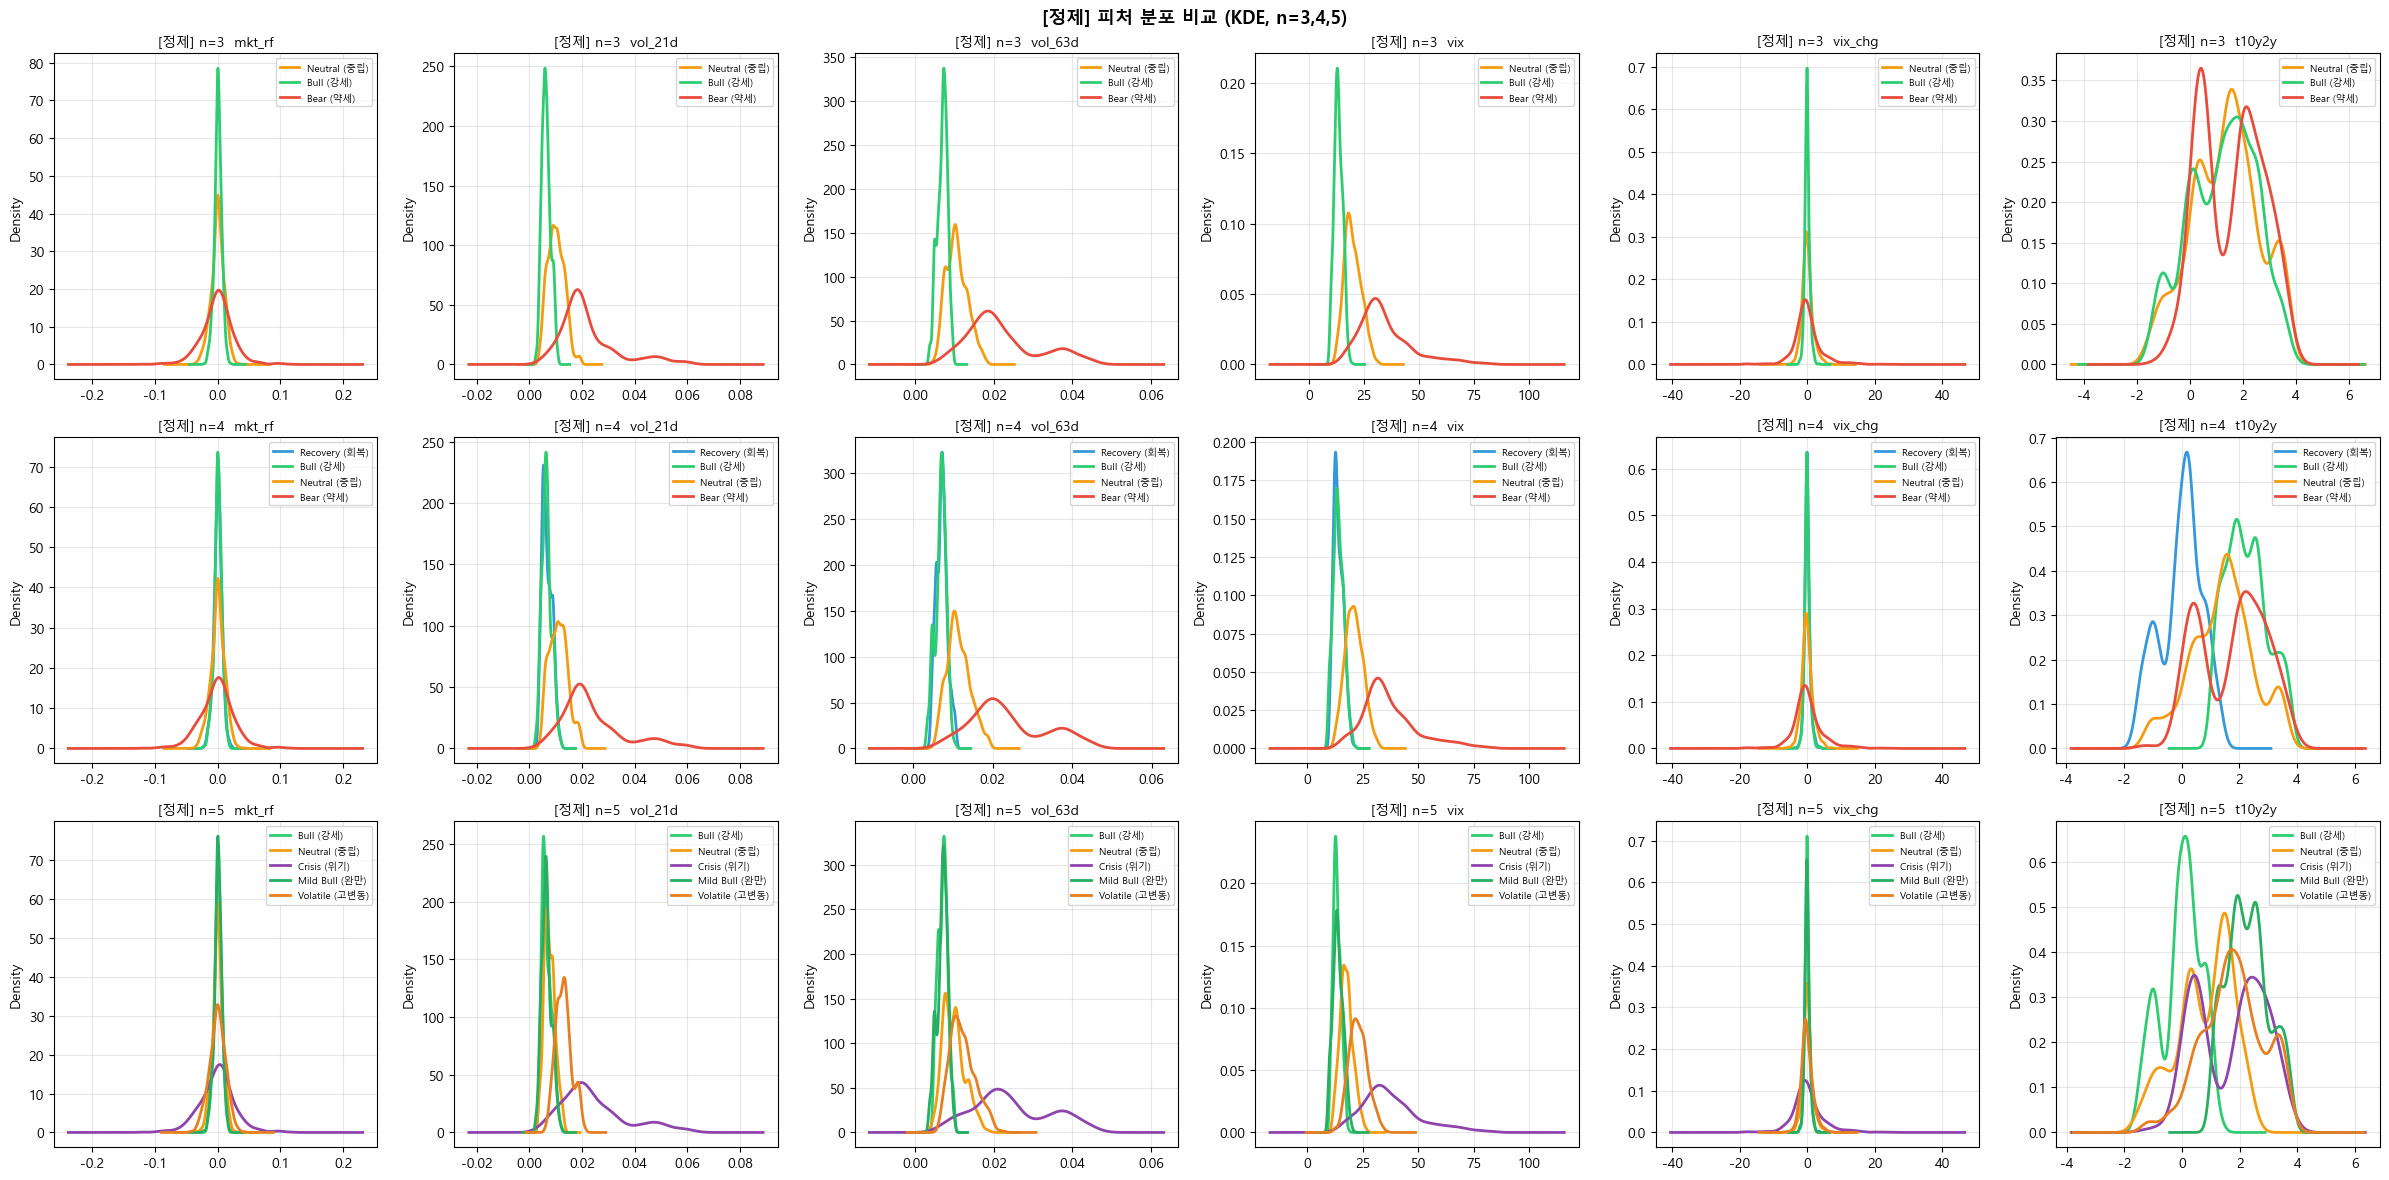

In [64]:
# ── [정제] 피처 분포 비교 (KDE) ──────────────────────────────────────────────
plot_feats_r = [f for f in REFINED_FEATS if f in feat_r.columns]

fig, axes = plt.subplots(3, len(plot_feats_r), figsize=(4*len(plot_feats_r), 12))

for row_idx, n in enumerate([3, 4, 5]):
    r      = results_r[n]
    st_arr = r["states"]
    s2l    = r["state_to_label"]
    uq     = sorted(s2l.keys())
    for col_idx, fname in enumerate(plot_feats_r):
        ax = axes[row_idx][col_idx]
        for s in uq:
            lbl  = s2l[s]
            vals = feat_r.loc[st_arr == s, fname].dropna()
            if len(vals) < 2:
                continue
            vals.plot.kde(ax=ax, label=lbl, color=get_color(lbl, uq.index(s)), lw=2)
        ax.set_title(f"[정제] n={n}  {fname}", fontsize=10)
        ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("[정제] 피처 분포 비교 (KDE, n=3,4,5)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "R8_kde_refined.png", bbox_inches="tight")
plt.show()

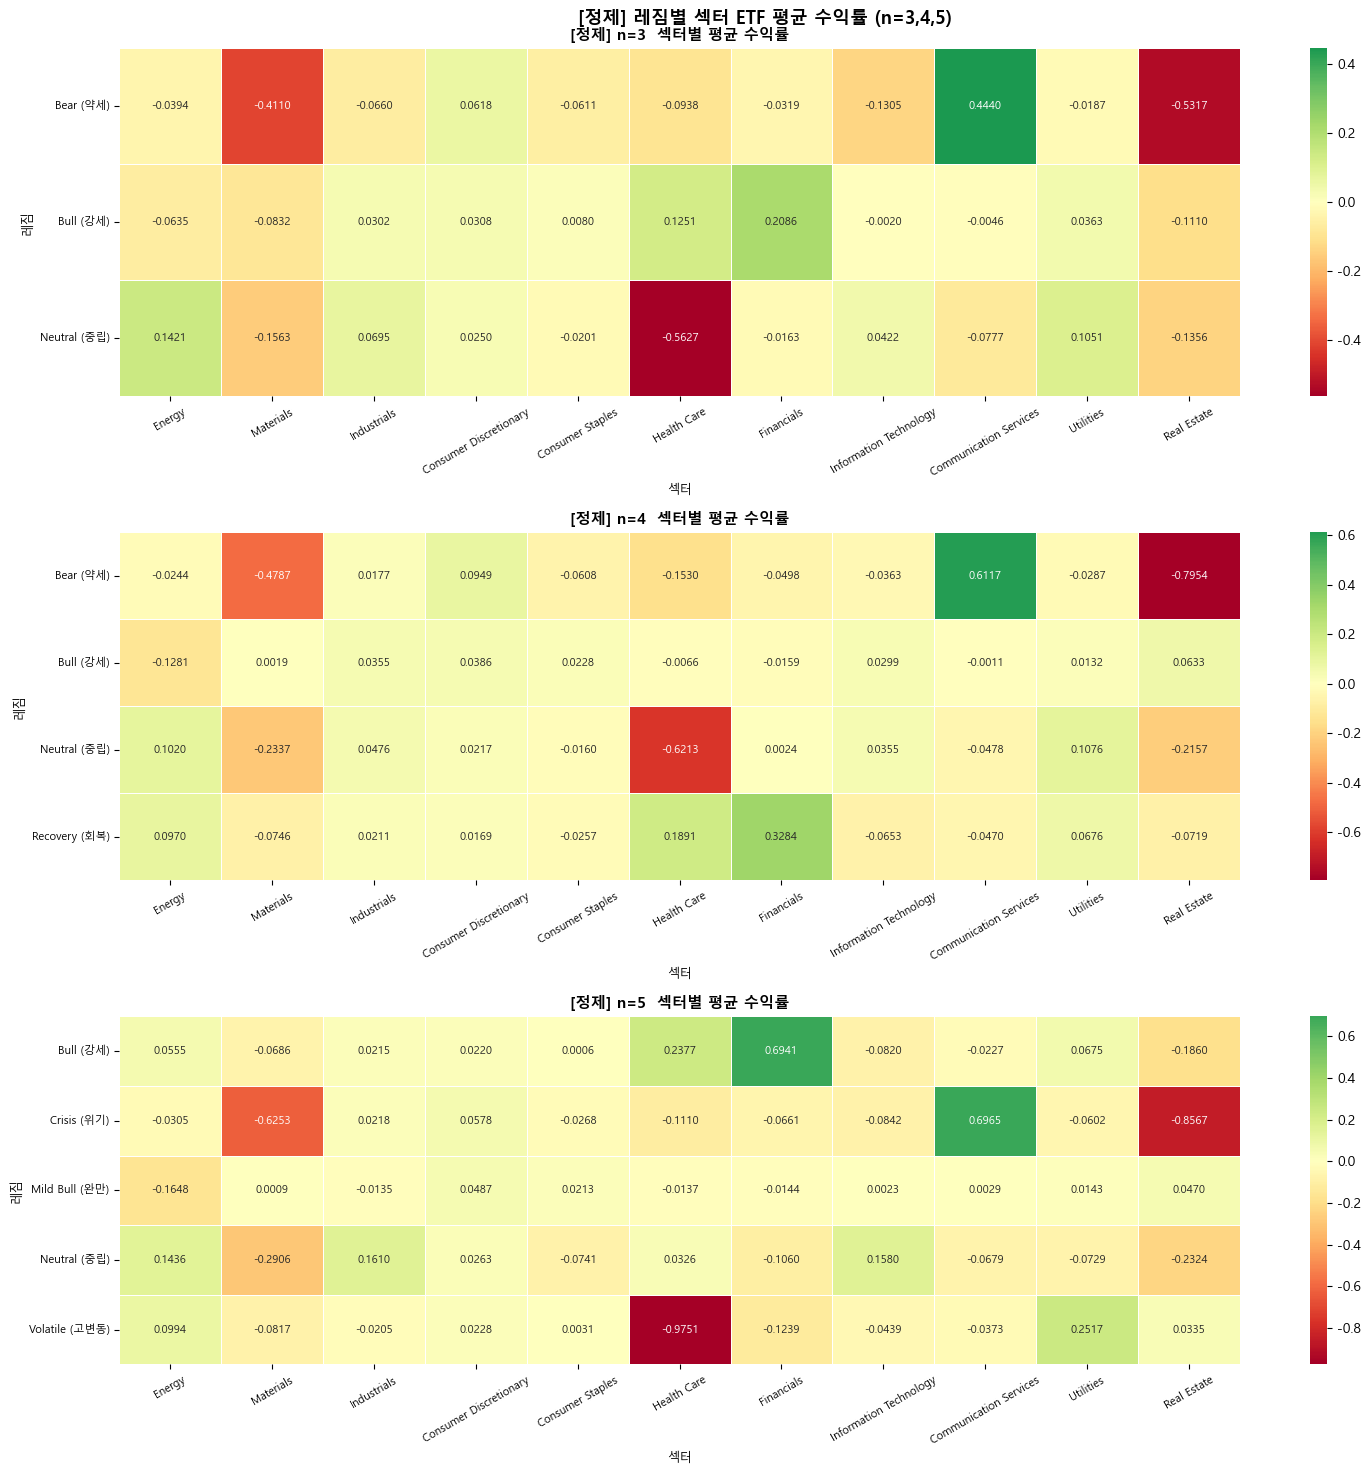

In [67]:
# ── [정제] 섹터 ETF 수익률 비교 ─────────────────────────────────────────────
sector_cols = [c for c in df_raw.columns if c.endswith("_ret") and c != "mkt_ret_ew"]

if sector_cols:
    fig, axes = plt.subplots(3, 1, figsize=(max(14, len(sector_cols)*1.4), 15))
    for ax, n in zip(axes, [3, 4, 5]):
        r   = results_r[n]
        tmp = feat_r[[]].copy()
        tmp["regime"] = [r["state_to_label"][s] for s in r["states"]]
        merged = tmp.join(df_raw[sector_cols], how="left")
        sm = merged.groupby("regime")[sector_cols].mean()
        sm.columns = [c.replace("_ret", "") for c in sm.columns]
        sns.heatmap(sm, annot=True, fmt=".4f", cmap="RdYlGn",
                    center=0, linewidths=0.5, ax=ax,
                    annot_kws={"size": 8})
        ax.set_title(f"[정제] n={n}  섹터별 평균 수익률", fontweight="bold", fontsize=11)
        ax.set_xlabel("섹터", fontsize=9)
        ax.set_ylabel("레짐", fontsize=9)
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.tick_params(axis="y", rotation=0, labelsize=8)
    plt.suptitle("[정제] 레짐별 섹터 ETF 평균 수익률 (n=3,4,5)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "R9_sector_refined.png", bbox_inches="tight")
    plt.show()
else:
    print("섹터 ETF 데이터 없음")

In [66]:
print("=" * 72)
print("   [정제 모델] 최종 요약")
print("=" * 72)
print(f"분석 기간 : {feat_df.index[0].date()} ~ {feat_df.index[-1].date()}")
print(f"사용 피처 ({len(REFINED_FEATS)}개): {REFINED_FEATS}")

print(f"{'n':>3}  {'k(파라미터수)':>14}  {'logL':>14}  {'BIC':>22}  수렴")
print("-" * 65)
for n in [3, 4, 5]:
    r    = results_r[n]
    mark = "  ◀ BIC 최적" if n == best_n_r else ""
    print(f"  {n}  {r['k']:>14d}  {r['logL']:>14.2f}  {r['bic']:>22.1f}  {r['model'].monitor_.converged}{mark}")

print(f"→ BIC 최적 레짐 수: n={best_n_r}")

r_best_r = results_r[best_n_r]
print(f"{'레짐':<18} {'비율':>6} {'일수':>6} {'수익':>8} {'변동':>8} {'VIX':>7}")
print("-" * 58)
for _, row in r_best_r["stats"].iterrows():
    print(f"  {row['label']:<16}  {row['pct']:5.1f}%  {int(row['count']):4d}일  "
          f"{row['mean_ret']*100:>+7.3f}%  {row['mean_vol']*100:>7.3f}%  {row['mean_vix']:>6.1f}")

print(f"─── 최근 10일 레짐 (정제 모델, n={best_n_r}) ─────────────────────────")
for dt, s in zip(feat_df.index[-10:], r_best_r["states"][-10:]):
    print(f"  {dt.date()}  →  {r_best_r['state_to_label'][s]}")

   [정제 모델] 최종 요약
분석 기간 : 2004-04-01 ~ 2026-02-27
사용 피처 (6개): ['mkt_rf', 'vol_21d', 'vol_63d', 'vix', 'vix_chg', 't10y2y']
  n        k(파라미터수)            logL                     BIC  수렴
-----------------------------------------------------------------
  3              89       -21952.94             242009950.7  True
  4             123       -19730.49             217509971.2  True
  5             159       -18187.83             200504035.9  True  ◀ BIC 최적
→ BIC 최적 레짐 수: n=5
레짐                     비율     일수       수익       변동     VIX
----------------------------------------------------------
  Bull (강세)          19.8%  1092일   +0.098%    0.666%    13.4
  Mild Bull (완만)     24.7%  1362일   +0.088%    0.661%    13.8
  Neutral (중립)       21.7%  1197일   +0.032%    0.770%    17.6
  Volatile (고변동)     24.6%  1356일   -0.005%    1.308%    23.0
  Crisis (위기)         9.2%   505일   -0.060%    2.427%    37.6
─── 최근 10일 레짐 (정제 모델, n=5) ─────────────────────────
  2026-02-13  →  Neutral (중립)
  2026-02-